In [1]:
import pandas as pd 
import numpy as np 
import ternary
import json
import os 
from datetime import datetime
from analysis_tools import *

# Since we do Nickel molybdenum
DEFAULT_FEATURE_SET = {
    "NiSO4 (mol/L)": ("input", "Conc Ni/Mo 10:1 liquid"),
    "Na2Mo (mol/L)": ("input", "Conc Mo/Ni 10:1 liquid"),
    "H2SO4 (mol/L)": ("input", "Conc H2SO4"),
    "Dep t (s)": ("input", "Dep time [s]"),
    "Dep I (mA/cm²)": ("input", "Current density mA/cm2"),
    "Dep T (C)": ("input", "Dep electrolye T [C]"),
    "integrated_area": ("goal", "Integrated stability at 10 [mA/cm2]"),
    "ML_optimization": ("meta", "ML_optimization"),
    "timestamp": ("meta", "timestamp"),
    "qUpperConfidence_beta": ("meta", "beta"),
}

DEFAULT_FEATURE_SET_XILE = {
    "Dep t (s)": ("input", "Dep time [s]"),
    "Dep I (mA/cm²)": ("input", "Current density mA/cm2"),
    "Dep T (C)": ("input", "Dep electrolye T [C]"),
    "integrated_area": ("goal", "Integrated stability at 10 [mA/cm2]"),
    "ML_optimization": ("meta", "ML_optimization"),
    "timestamp": ("meta", "timestamp"),
    "qUpperConfidence_beta": ("meta", "beta"),
}
def reformat_timestamp(ts):
    return datetime.strptime(ts, "%d.%m.%Y_%H-%M").strftime("%d_%m_%Y_%H_%M")

source_root = "/Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot"

# Adaptive beta run 2 failed
subdir_beta_run_2 = "Ni_Mo_Optimization_Jonas/ML/Adaptive_beta_run_2_failed"
path_suggested_exps = os.path.join(source_root, subdir_beta_run_2)
path_input_params = os.path.join(source_root, subdir_beta_run_2, "Input_parameters_database.json")
path_goal_params = os.path.join(source_root, subdir_beta_run_2, "Goal_parameters_database.json")

# Original dataset
subdir_og = "Ni_Mo_optimization_run_01_05_25/ML"
path_suggested_exps_og = os.path.join(source_root, subdir_og)
path_input_params_og = os.path.join(source_root, subdir_og, "Input_parameters_database.json")
path_goal_params_og = os.path.join(source_root, subdir_og, "Goal_parameters_database.json")

# Adaptive beta run 3 failed
subdir_beta_5_fail = "Ni_Mo_Optimization_Jonas/ML/Adaptive_beta_run_3_failed"
path_suggested_exps_beta_5_fail = os.path.join(source_root, subdir_beta_5_fail)
path_input_params_beta_5_fail = os.path.join(source_root, subdir_beta_5_fail, "Input_parameters_database.json")
path_goal_params_beta_5_fail = os.path.join(source_root, subdir_beta_5_fail, "Goal_parameters_database.json")

# Beta = 5 run
subdir_beta_5 = "Ni_Mo_Optimization_Jonas/ML/Beta_5"
path_suggested_exps_beta_5 = os.path.join(source_root, subdir_beta_5)
path_input_params_beta_5 = os.path.join(source_root, subdir_beta_5, "Input_parameters_database.json")
path_goal_params_beta_5 = os.path.join(source_root, subdir_beta_5, "Goal_parameters_database.json")

# Beta = 1 run
subdir_beta_1 = "Ni_Mo_Optimization_Jonas/ML/Beta_1"
path_suggested_exps_beta_1 = os.path.join(source_root, subdir_beta_1)
path_input_params_beta_1 = os.path.join(source_root, subdir_beta_1, "Input_parameters_database.json")
path_goal_params_beta_1 = os.path.join(source_root, subdir_beta_1, "Goal_parameters_database.json")

# Xile paper
subdir_Xile = "Ni_Mo_Optimization_Jonas/Ni_Mo_optimization_Xile_test/ML"
path_suggested_exps_Xile = os.path.join(source_root, subdir_Xile)
path_input_params_Xile = os.path.join(source_root, subdir_Xile, "Input_parameters_database.json")
path_goal_params_Xile = os.path.join(source_root, subdir_Xile, "Goal_parameters_database.json")

print(os.path.exists(path_input_params_Xile))
# Original dataset
df_og = get_df_from_ML_optimization(path_suggested_exps=path_suggested_exps_og, 
                            path_input_params=path_input_params_og, 
                            path_goal_params=path_goal_params_og)

# Failed optimization adaptive beta run 1 
df = get_df_from_ML_optimization(path_suggested_exps=path_suggested_exps, 
                            path_input_params=path_input_params, 
                            path_goal_params=path_goal_params)

# Faild optimization adaptive beta run 2 
df_2 = get_df_from_ML_optimization(path_suggested_exps=path_suggested_exps_beta_5_fail, 
                            path_input_params=path_input_params_beta_5_fail, 
                            path_goal_params=path_goal_params_beta_5_fail)

# Optimization run fixed beta = 5 
df_beta_5 = get_df_from_ML_optimization(path_suggested_exps=path_suggested_exps_beta_5, 
                            path_input_params=path_input_params_beta_5, 
                            path_goal_params=path_goal_params_beta_5)

# Optimization run fixed beta = 1
df_beta_1 = get_df_from_ML_optimization(path_suggested_exps=path_suggested_exps_beta_1, 
                            path_input_params=path_input_params_beta_1, 
                            path_goal_params=path_goal_params_beta_1)
# df from Xile paper 
df_Xile = get_df_from_ML_optimization(path_suggested_exps=None, 
                            path_input_params=path_input_params_Xile, 
                            path_goal_params=path_goal_params_Xile,
                            feature_set=DEFAULT_FEATURE_SET_XILE)

# This dataset includes also data with IR corrections 
datasets = [df, df_2, df_og, df_beta_5, df_beta_1]
datasets = [df_og, df_beta_5, df_beta_1]
datasets.to_csv("/mnt/data/datasets.csv", index=False)

print("datasets.csv has been saved successfully!")

complete_dataset = pd.concat(datasets, ignore_index=True)
complete_dataset["timestamp"] = complete_dataset["timestamp"].apply(reformat_timestamp)

True


AttributeError: 'list' object has no attribute 'to_csv'

# Analyzing Curves

<class 'list'>


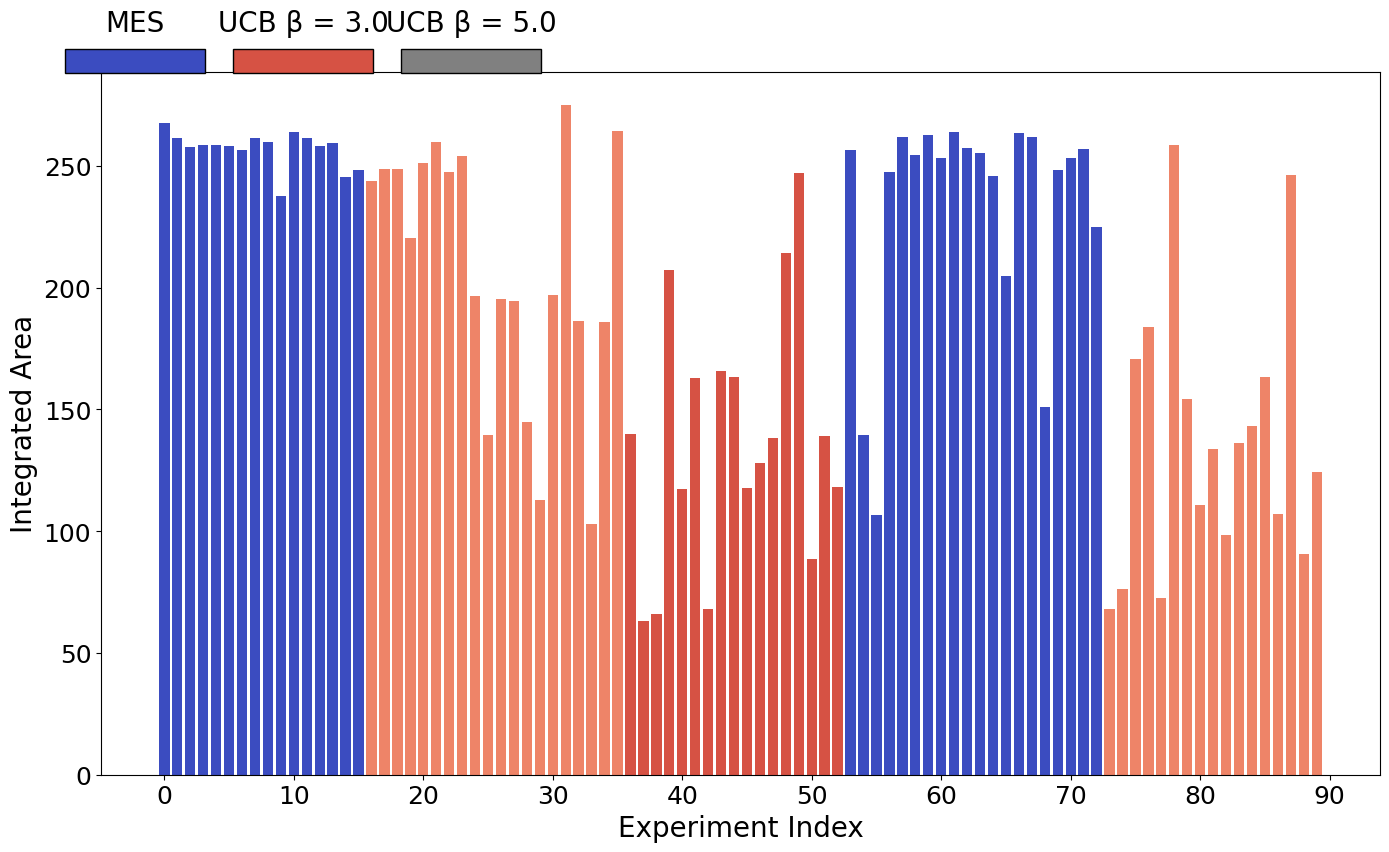

[(0, 15, ['qMaxValueEntropySearch', 0.0]), (16, 35, ['qUpperConfidenceBound', 4.0]), (36, 52, ['qUpperConfidenceBound', 3.0]), (53, 72, ['qMaxValueEntropySearch', 0.0]), (73, 89, ['qUpperConfidenceBound', 4.0])]


/var/folders/y7/nkq5y8bx3nl3kcn3ndsw71t80000gp/T/ipykernel_97494/854773600.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phases["index"] = phases.index


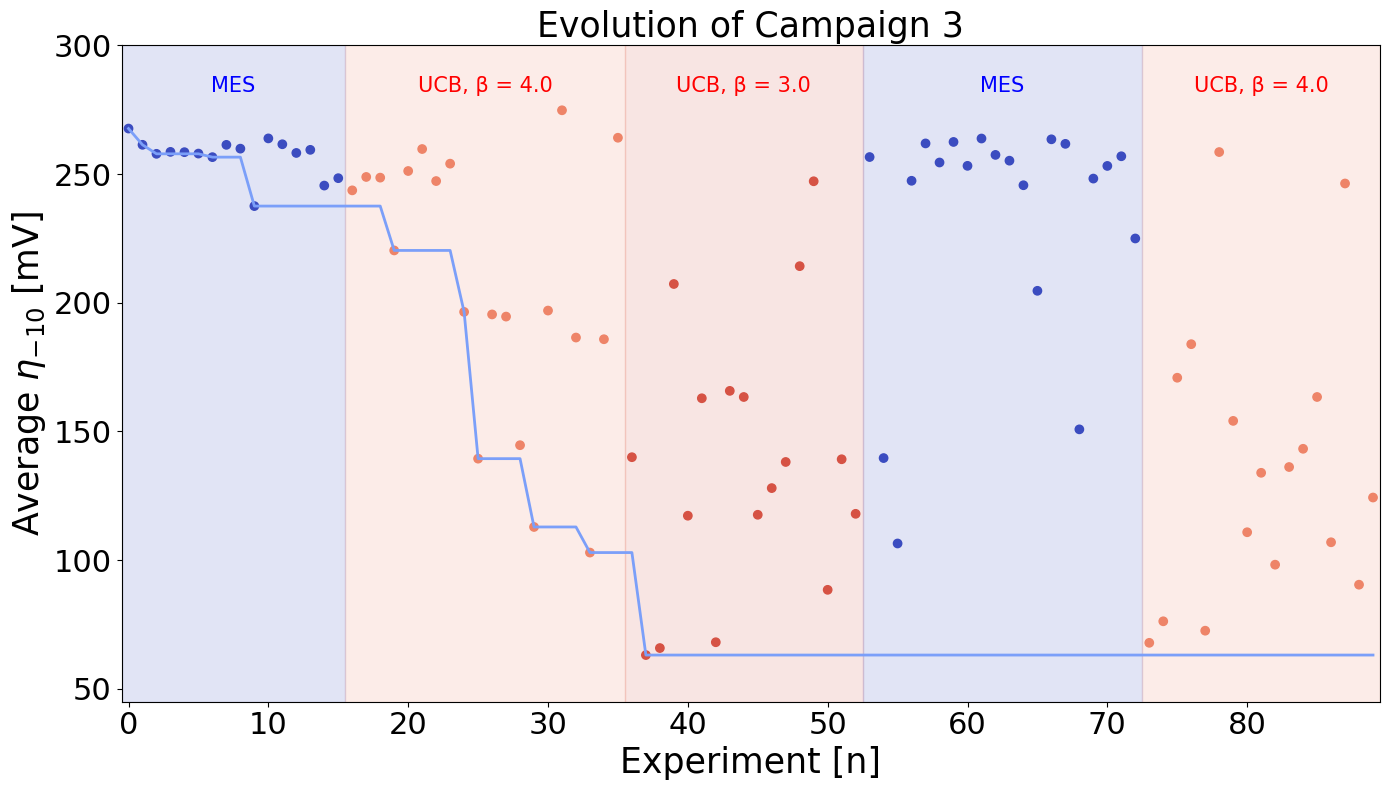

In [ ]:
datasets = [df_og, df_beta_5, df_beta_1]
combined_df = pd.concat(datasets, ignore_index=True)
combined_df.to_csv("datasets_jonas.csv", index=False)
print(type(datasets))
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.ticker import MaxNLocator
import os 
# Use a red-to-blue colormap
cmap = plt.get_cmap("coolwarm")

# Define beta-to-color mapping
beta_colors = {
    0: cmap(0.0),    # red
    4: cmap(0.8),
    3: cmap(0.9),
    2: cmap(0.6),
    1: cmap(0.8),
    0.5: cmap(1.0)   # blue
}

plot_df = df_og.iloc[:90]

integrated_areas = plot_df["integrated_area"] / 100
ML_optimization = plot_df["ML_optimization"]
betas = plot_df["qUpperConfidence_beta"]

x = np.arange(len(integrated_areas))
colors = [beta_colors.get(b, 'gray') for b in betas]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.bar(x, integrated_areas, color=colors)

# Set axis labels and title
ax.set_xlabel("Experiment Index", fontsize=20)
ax.set_ylabel("Integrated Area", fontsize=20)
ax.tick_params(labelsize=18)

# Prepare the top legend strip (outside the plot)
unique_phases = df[["ML_optimization", "qUpperConfidence_beta"]].drop_duplicates()
unique_phases = unique_phases.sort_values("ML_optimization")  # Optional: sort by phase name

# Add colored rectangles and text above the plot
top_y = 0.98  # relative y-position in figure coordinates
x_offset = 0.05

box_width = 0.1
spacing = 0.02

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

for i, row in enumerate(unique_phases.itertuples()):
    phase = row.ML_optimization
    beta = row.qUpperConfidence_beta
    color = beta_colors.get(beta, 'gray')
    
    x_pos = x_offset + i * (box_width + spacing)

    # Color box
    fig.patches.append(
        plt.Rectangle((x_pos, top_y), box_width, 0.03,
                      transform=fig.transFigure, facecolor=color, edgecolor='black')
    )
    # Label
    if beta == 0:
        fig.text(x_pos + box_width / 2, top_y + 0.045, f"MES", 
        ha='center', va='bottom', fontsize=20)
    else:

        fig.text(x_pos + box_width / 2, top_y + 0.045, f"UCB β = {beta}", 
                ha='center', va='bottom', fontsize=20)

savepath = "/Users/pvifr/Desktop/ElectrochemicalDataAnalysis/Ni_Mo_paper/Figures/BO"
# Adjust layout
plt.tight_layout()  # leave space at top for labels
plt.savefig(os.path.join(savepath, "BO_evolution.png"))
plt.show()

fig, ax = plt.subplots(figsize=(14, 8))

# Use same x and colors as before
x = np.arange(len(integrated_areas))
colors = [beta_colors.get(b, 'gray') for b in betas]

# Scatter points with color code
ax.scatter(x, integrated_areas, color=colors)

# Plot the evolution line (minimum up to each point)
min_integrated_area = integrated_areas.iloc[0]
evolution_line = []
for val in integrated_areas:
    if val < min_integrated_area:
        min_integrated_area = val
    evolution_line.append(min_integrated_area)

ax.plot(evolution_line, color=cmap(0.2), label="Best-so-far", lw = 2)
# Get start/end indices of each phase
phases = plot_df[["ML_optimization", "qUpperConfidence_beta"]]
phases["index"] = phases.index

# Group by consecutive identical phases
from itertools import groupby
from operator import itemgetter

phase_blocks = []
for k, g in groupby(enumerate(phases[["ML_optimization", "qUpperConfidence_beta"]].values.tolist()), key=itemgetter(1)):
    g = list(g)
    indices = [i for i, _ in g]
    phase_blocks.append((indices[0], indices[-1], k))

# Draw shaded spans and add labels
for start, end, (ml_opt, beta) in phase_blocks:
    color = beta_colors.get(beta, "gray")
    label = "MES" if beta == 0 else f"UCB, β = {beta}"
    
    label_color = "blue" if beta == 0 else "red"
    # Shading
    ax.axvspan(start - 0.5, end + 0.5, color=color, alpha=0.15)
    
    # Centered text label
    center = (start + end) / 2
    max_y = max(integrated_areas) * 1.02
    ax.text(center, max_y, label, color=label_color, ha="center", va="bottom", fontsize=15)

print(phase_blocks)
# Labels and formatting
ax.set_ylim(45, 300)
ax.set_xlim(min(start for start, _, _ in phase_blocks) - 0.5,
            max(end for _, end, _ in phase_blocks) + 0.5)
ax.set_xlabel("Experiment [n]", fontsize=25)
ax.set_ylabel(r"Average $\eta_{-10}$ [mV]", fontsize=25)
ax.tick_params(labelsize=22)
ax.set_title("Evolution of Campaign 3", fontsize = 25)
#ax.legend(fontsize=20, loc = "lower left")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(os.path.join(savepath, "BO_evolution_line.png"))
plt.show()

# Investigating the different strategies

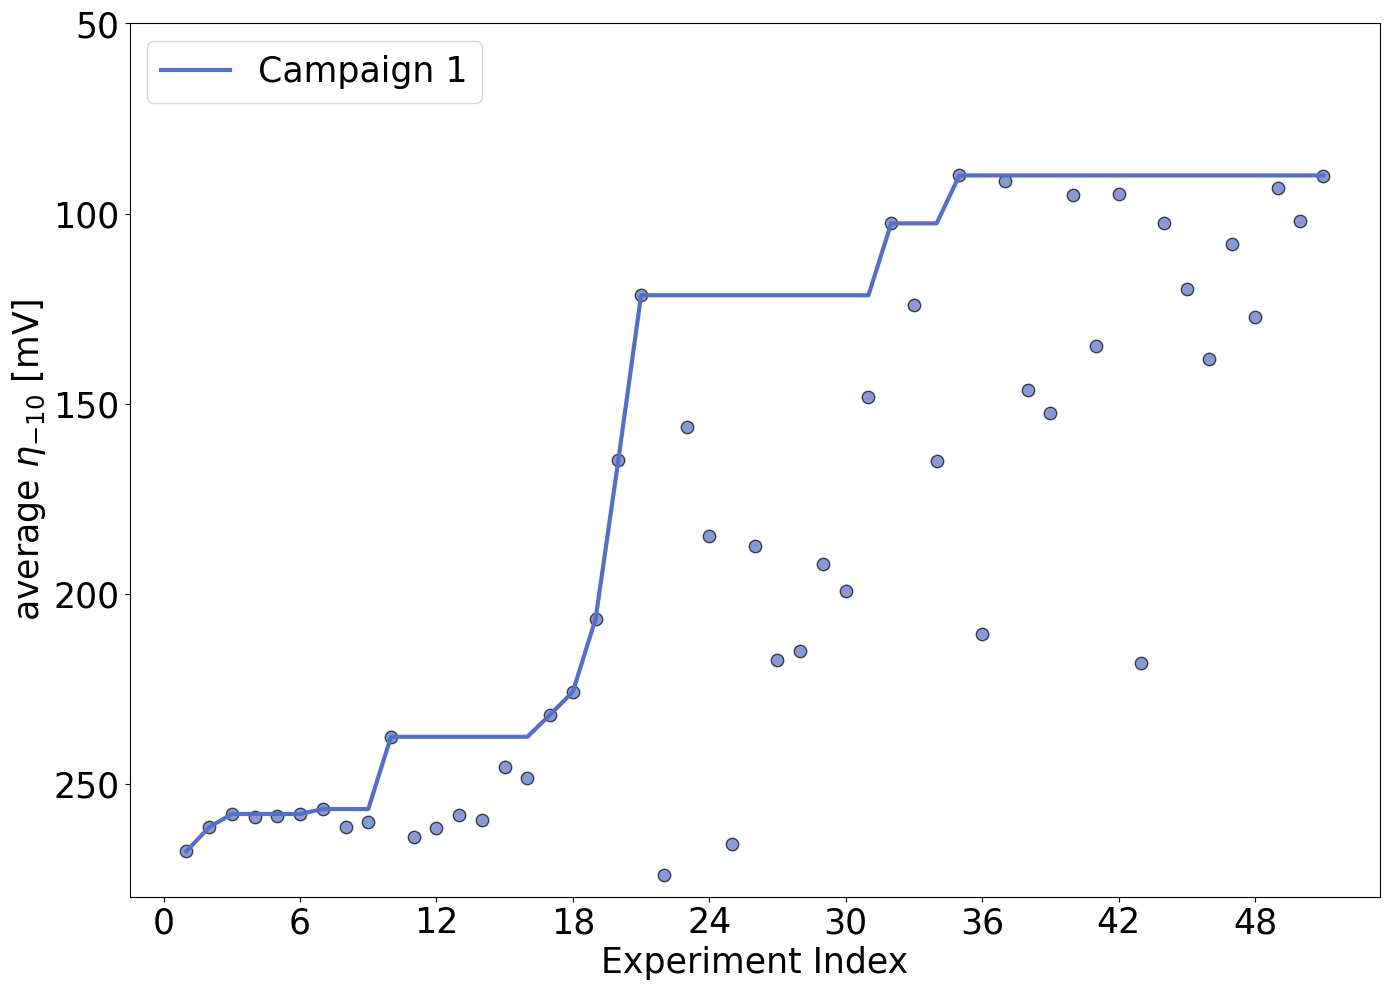

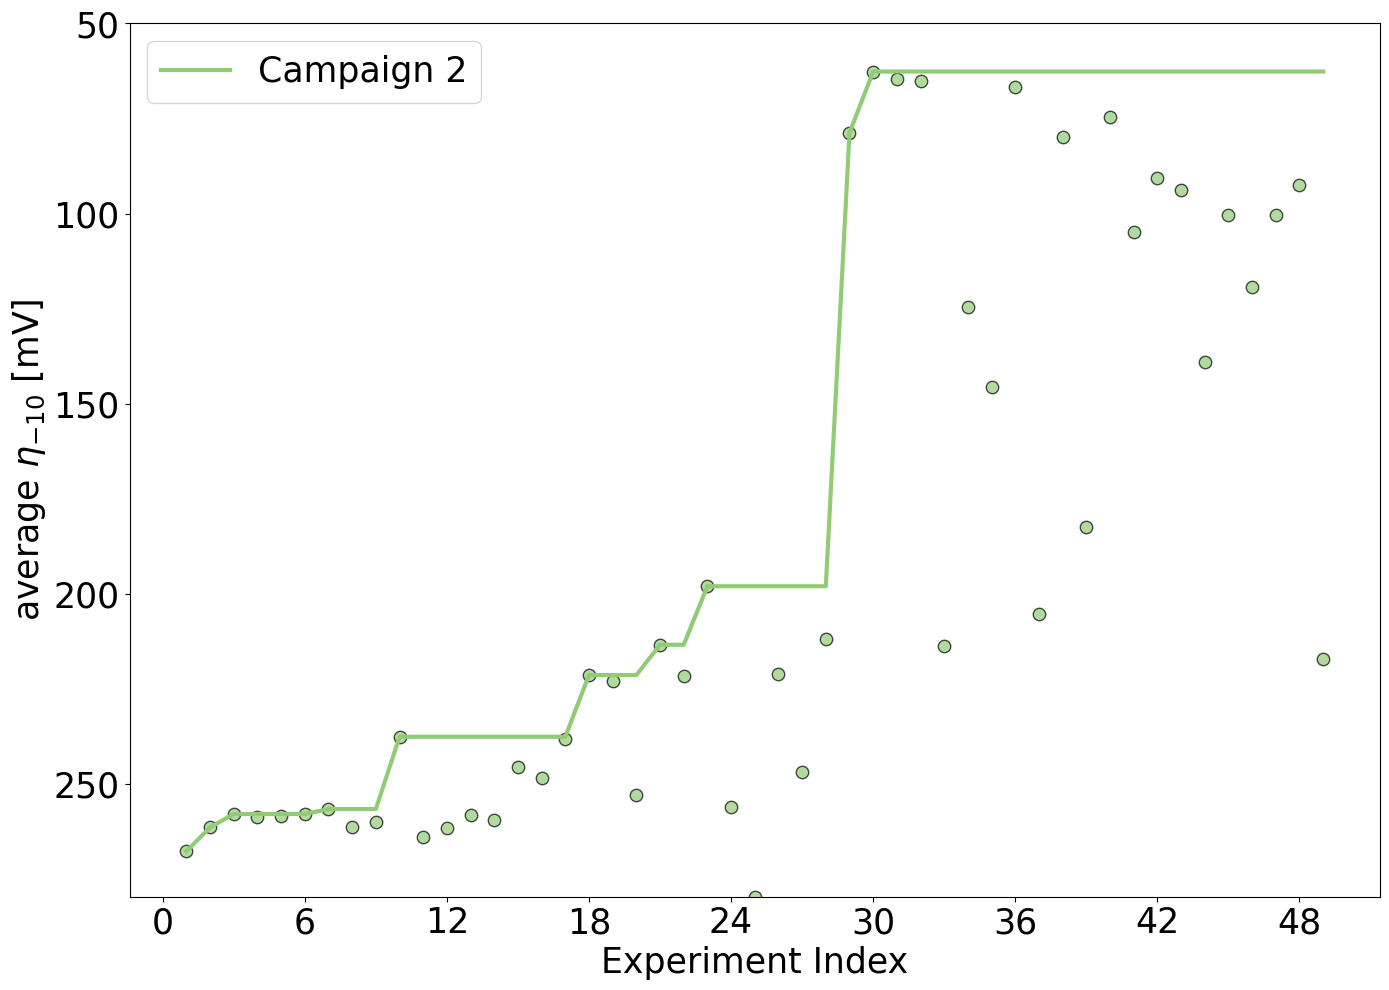

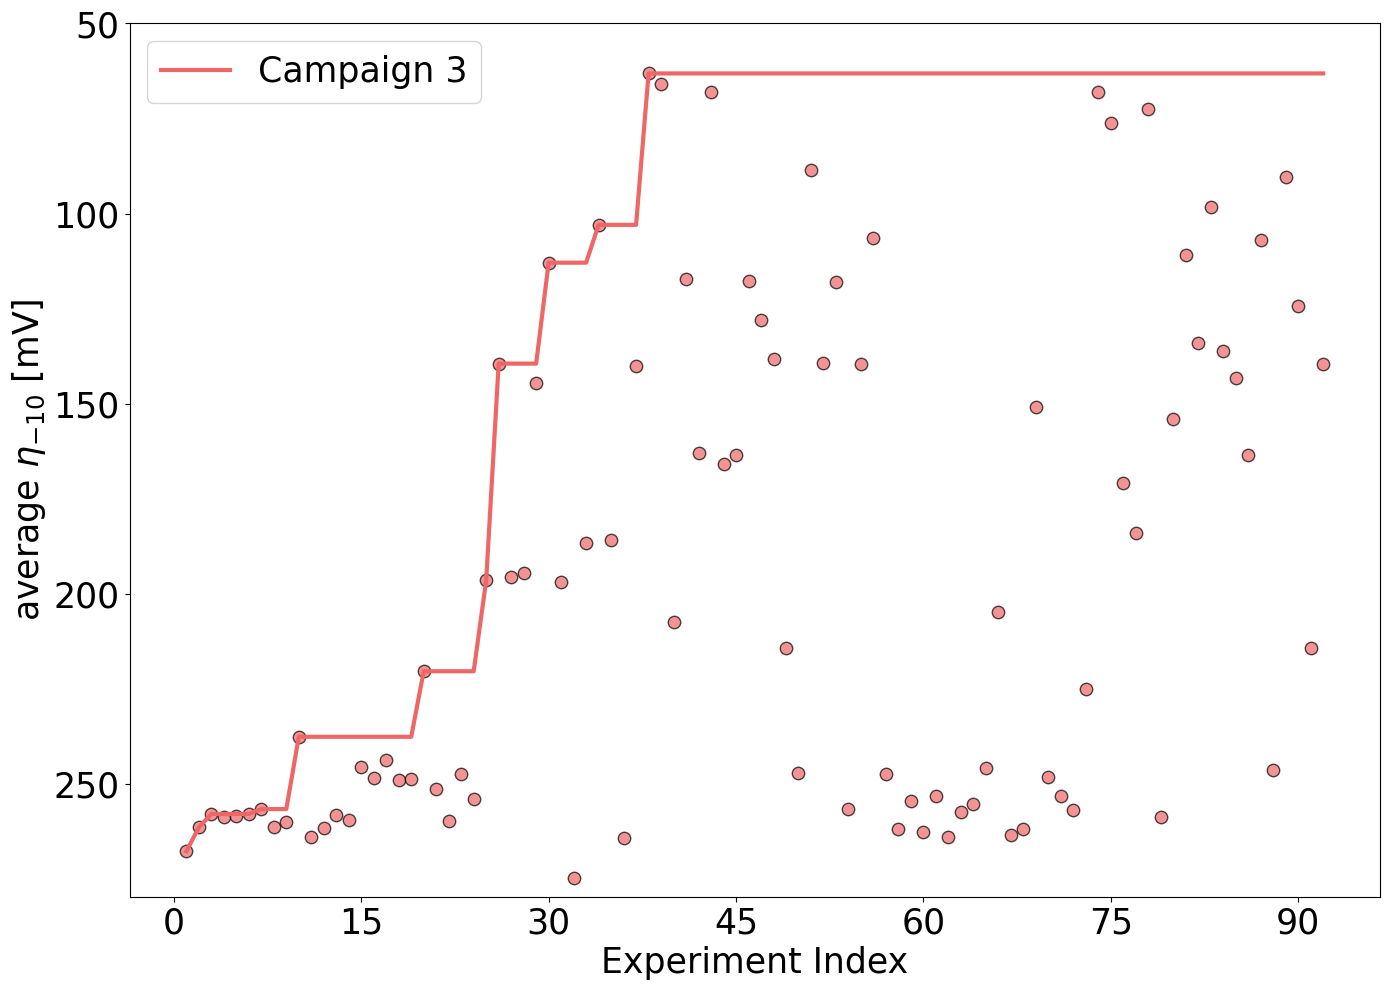

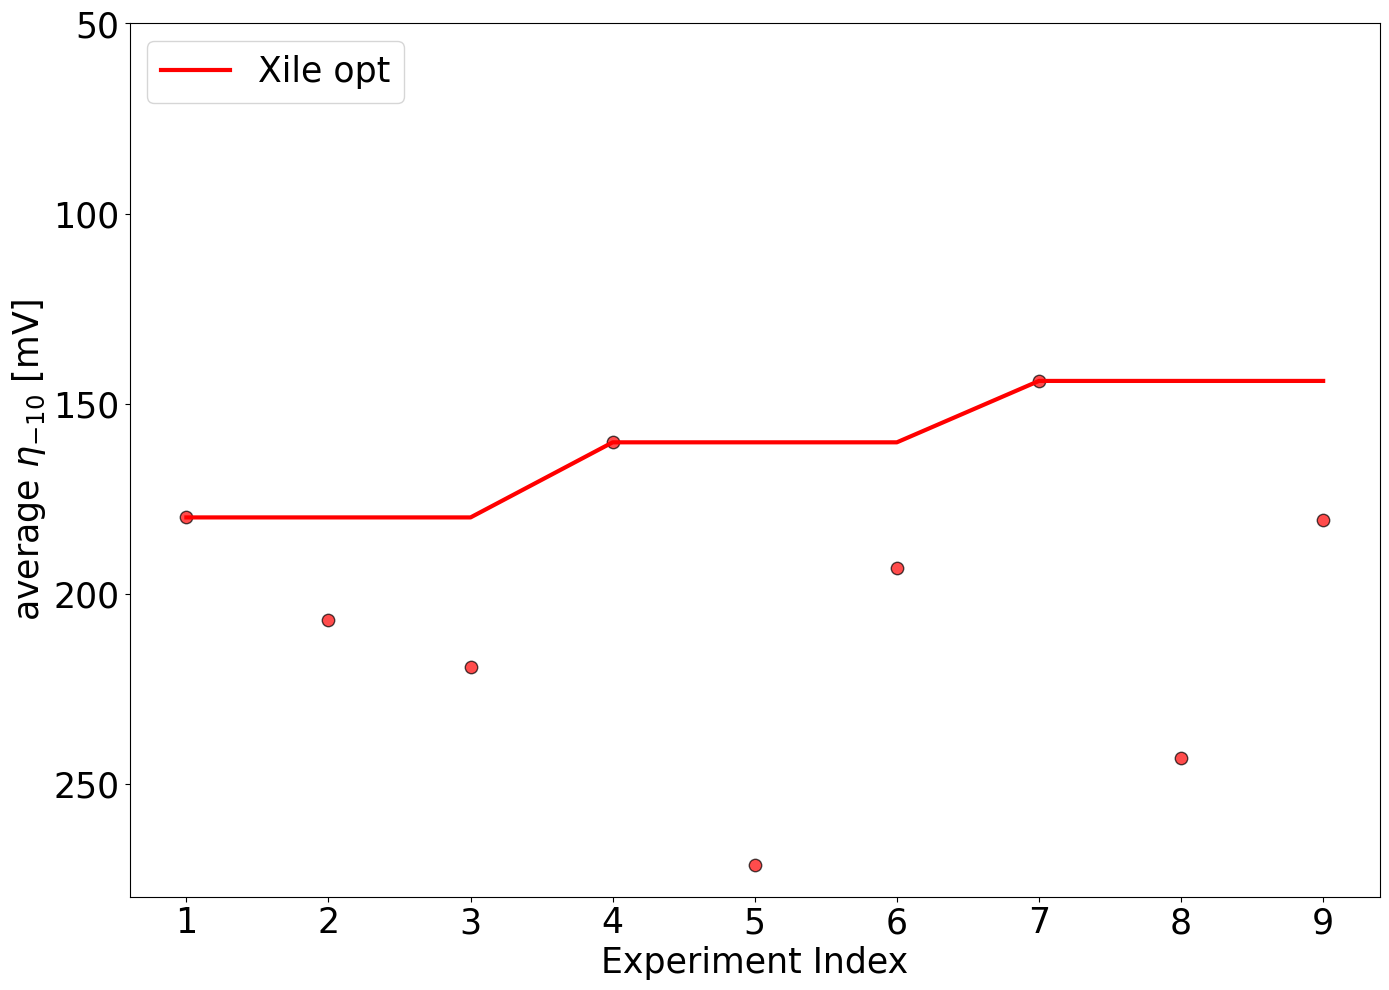

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.ticker import MaxNLocator
import os
from itertools import groupby
from operator import itemgetter
from matplotlib.patches import Patch

# Use a qualitative colormap for distinct categories
cmap = plt.get_cmap("coolwarm")  # Good alternatives: "Set1", "Dark2", "Paired"

save_path_BO_examples = "Figures/BO"
# Distinct colors for each beta
beta_colors = {
    0: cmap(0),    # blue
    4: cmap(1),    # orange
    3: cmap(2),    # green
    2: cmap(3),    # red
    1: cmap(4),    # purple
    0.5: cmap(5)   # brown
}

def plot_trace(df, ax, label_prefix, line_color, use_beta_coloring=False):
    integrated_areas = df["integrated_area"] / 100
    betas = df["qUpperConfidence_beta"]
    x = np.arange(len(integrated_areas)) + 1

    if use_beta_coloring:
        # Per-point color by beta
        for i, (x_i, y_i, beta) in enumerate(zip(x, integrated_areas, betas)):
            color = beta_colors.get(beta, "gray")
            ax.scatter(x_i, y_i, color=line_color, edgecolors='k', alpha=0.8, s=80)
    else:
        ax.scatter(x, integrated_areas, color=line_color, edgecolors='k', alpha=0.7, s=80)

    # Best-so-far line
    min_area = integrated_areas.iloc[0]
    evolution_line = []
    for val in integrated_areas:
        if val < min_area:
            min_area = val
        evolution_line.append(min_area)
    ax.plot(x, evolution_line, color=line_color, label=f"{label_prefix}", linewidth=3)

    return integrated_areas


# Plot
# Plot 1: df_og (Campaign 1)
# --- Compute shared y-limit max ---
ymin = 50
ymin = 50
ymax = max(
    max(df_og["integrated_area"] / 100),
    max(df_beta_1["integrated_area"] / 100),
    max(df_beta_5["integrated_area"] / 100), 
    max(df_Xile["integrated_area"] / 100), 
)


# Add color codes from spider plot 
colors = {"beta_1" : "#5470c6",
          "beta_5" : "#91cc75", 
          "original": "#ee6666", 
          "xile" : "red"}

# Plot 2: df_beta_1 (Campaign 2)
fig2, ax2 = plt.subplots(figsize=(14, 10))
areas_beta_1 = plot_trace(df_beta_1, ax2, "Campaign 1", line_color=colors["beta_1"])
ax2.set_ylim(ymax, ymin)  # Flipped here directly
ax2.set_xlabel("Experiment Index", fontsize=25)
ax2.set_ylabel(r"average $\eta_{-10}$ [mV]", fontsize=25)
ax2.tick_params(labelsize=25)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.legend(loc="upper left", fontsize=25)
plt.tight_layout()
plt.savefig(os.path.join(save_path_BO_examples, "Campaign_1_Optimization.png"))

# Plot 3: df_beta_5 (Campaign 3)
fig3, ax3 = plt.subplots(figsize=(14, 10))
areas_beta_5 = plot_trace(df_beta_5, ax3, "Campaign 2", line_color=colors["beta_5"])
ax3.set_ylim(ymax, ymin)  # Flipped here directly
ax3.set_xlabel("Experiment Index", fontsize=25)
ax3.set_ylabel(r"average $\eta_{-10}$ [mV]", fontsize=25)
ax3.tick_params(labelsize=25)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))
ax3.legend(loc="upper left", fontsize=25)
plt.tight_layout()
plt.savefig(os.path.join(save_path_BO_examples, "Campaign_2_Optimization.png"))


# Here change the colors 
# Plot 1: df_og (Campaign 1)
fig1, ax1 = plt.subplots(figsize=(14, 10))
areas_og = plot_trace(df_og, ax1, "Campaign 3", line_color=colors["original"])
ax1.set_ylim(ymax, ymin)  # Flipped here directly
ax1.set_xlabel("Experiment Index", fontsize=25)
ax1.set_ylabel(r"average $\eta_{-10}$ [mV]", fontsize=25)
ax1.tick_params(labelsize=25)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.legend(loc="upper left", fontsize=25)
plt.tight_layout()
plt.savefig(os.path.join(save_path_BO_examples, "Campaign_3_Optimization.png"))


# Here change the colors 
# Plot 1: df_og (Campaign 1)
fig4, ax4 = plt.subplots(figsize=(14, 10))
areas_og = plot_trace(df_Xile, ax4, "Xile opt", line_color=colors["xile"])
ax4.set_ylim(ymax, ymin)  # Flipped here directly
ax4.set_xlabel("Experiment Index", fontsize=25)
ax4.set_ylabel(r"average $\eta_{-10}$ [mV]", fontsize=25)
ax4.tick_params(labelsize=25)
ax4.xaxis.set_major_locator(MaxNLocator(integer=True))
ax4.legend(loc="upper left", fontsize=25)
plt.tight_layout()
plt.savefig(os.path.join(save_path_BO_examples, "Campaign_Xile_Optimization.png"))

# Evolution of how BO chooses points

Index(['NiSO4 (mol/L)', 'Na2Mo (mol/L)', 'H2SO4 (mol/L)', 'Dep t (s)',
       'Dep I (mA/cm²)', 'Dep T (C)', 'integrated_area', 'ML_optimization',
       'timestamp', 'qUpperConfidence_beta'],
      dtype='object')


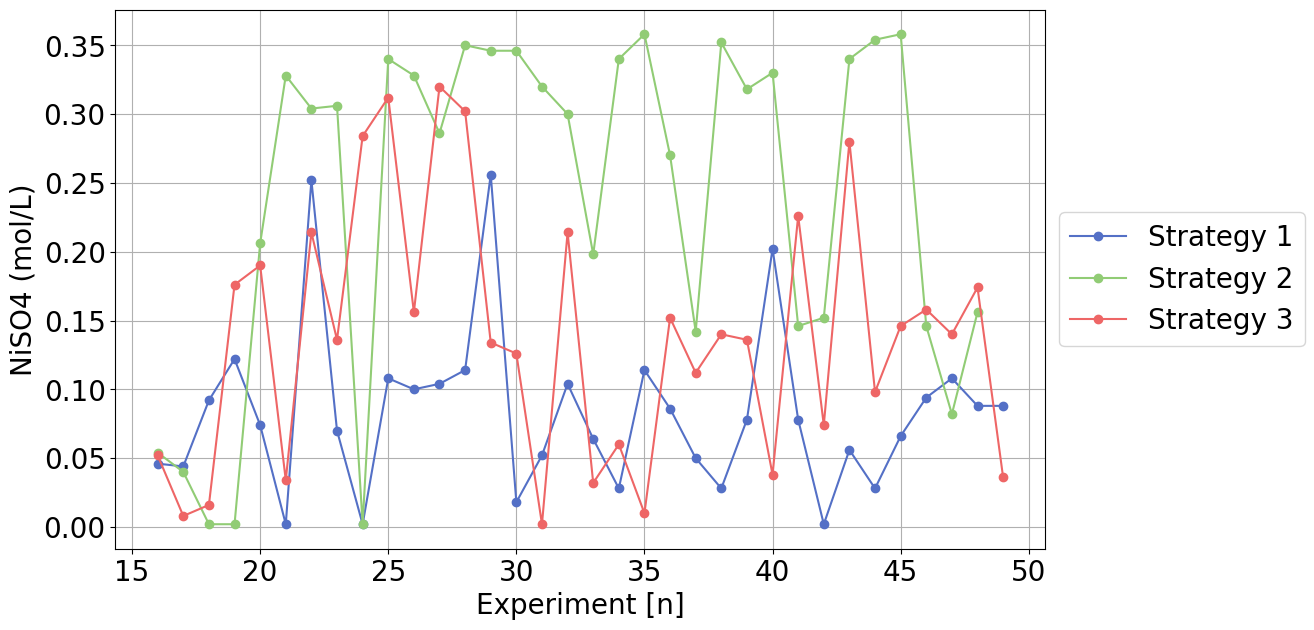

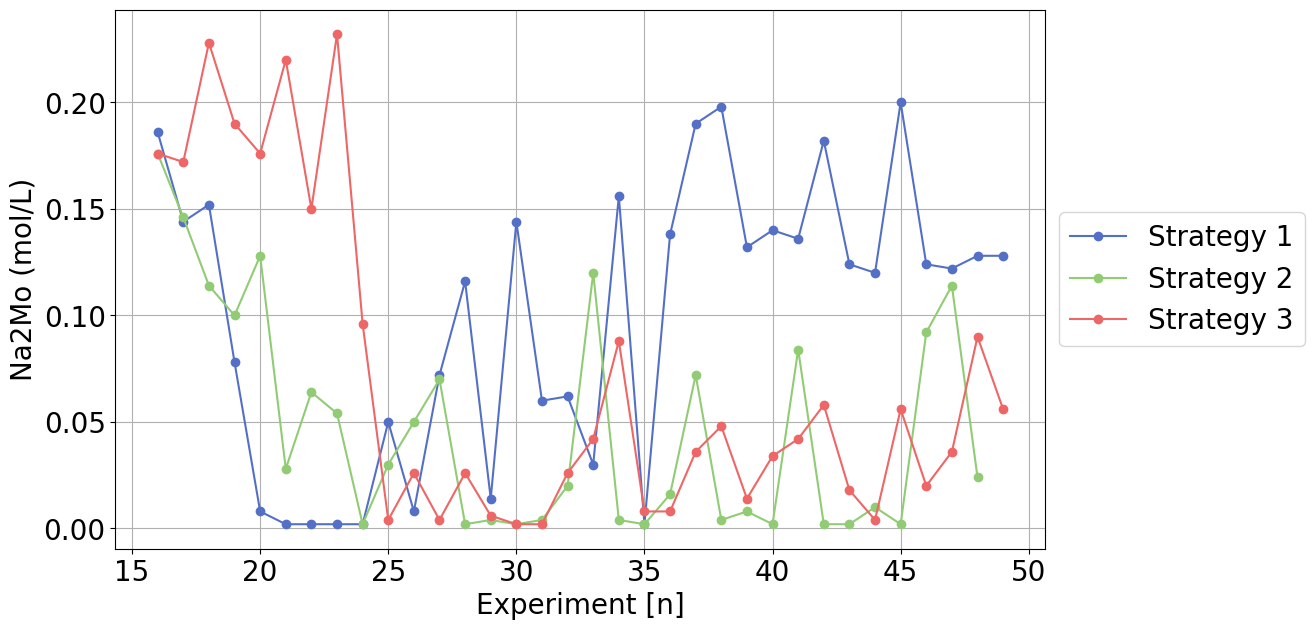

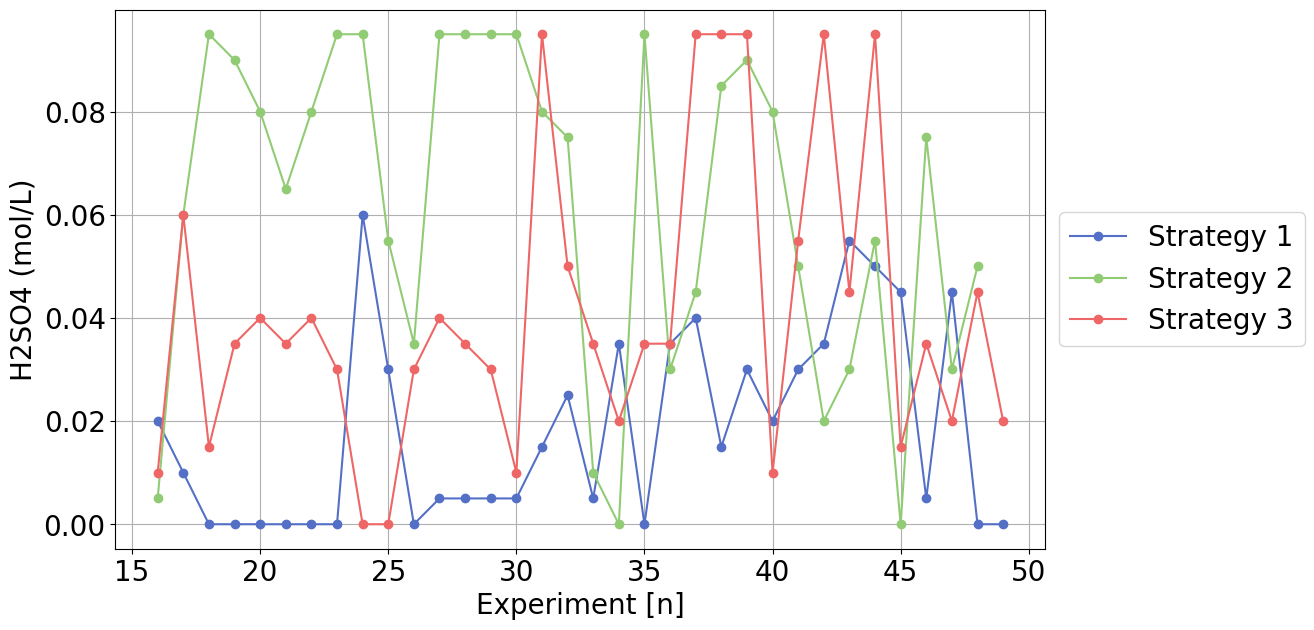

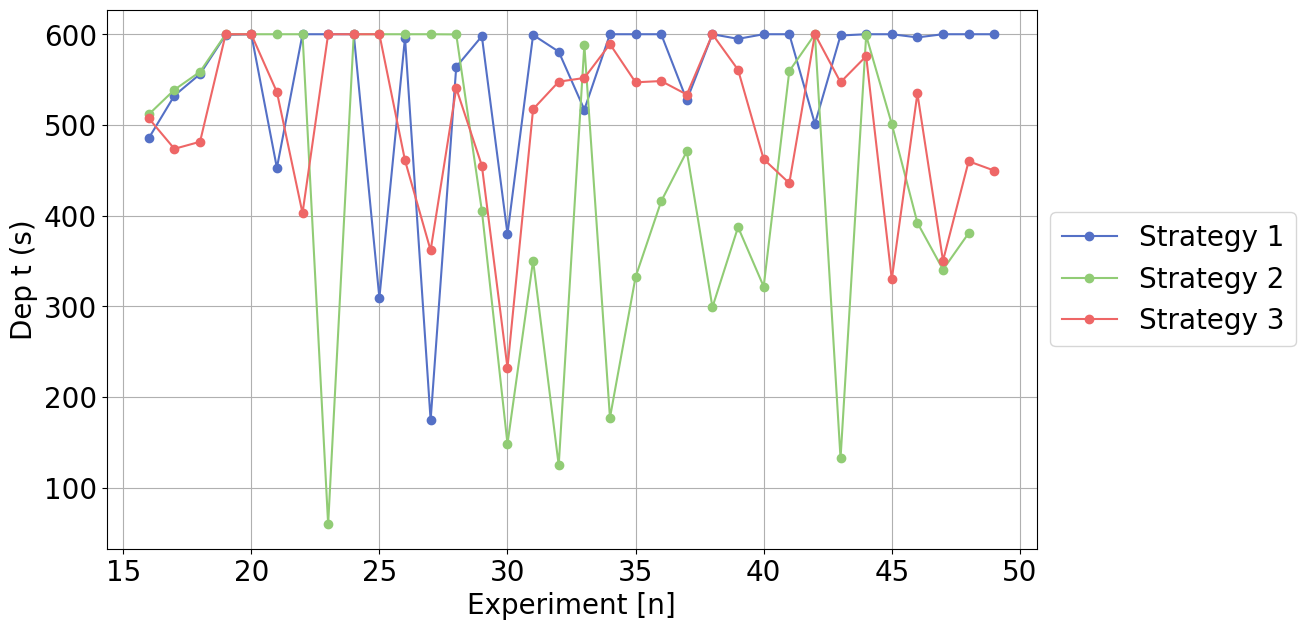

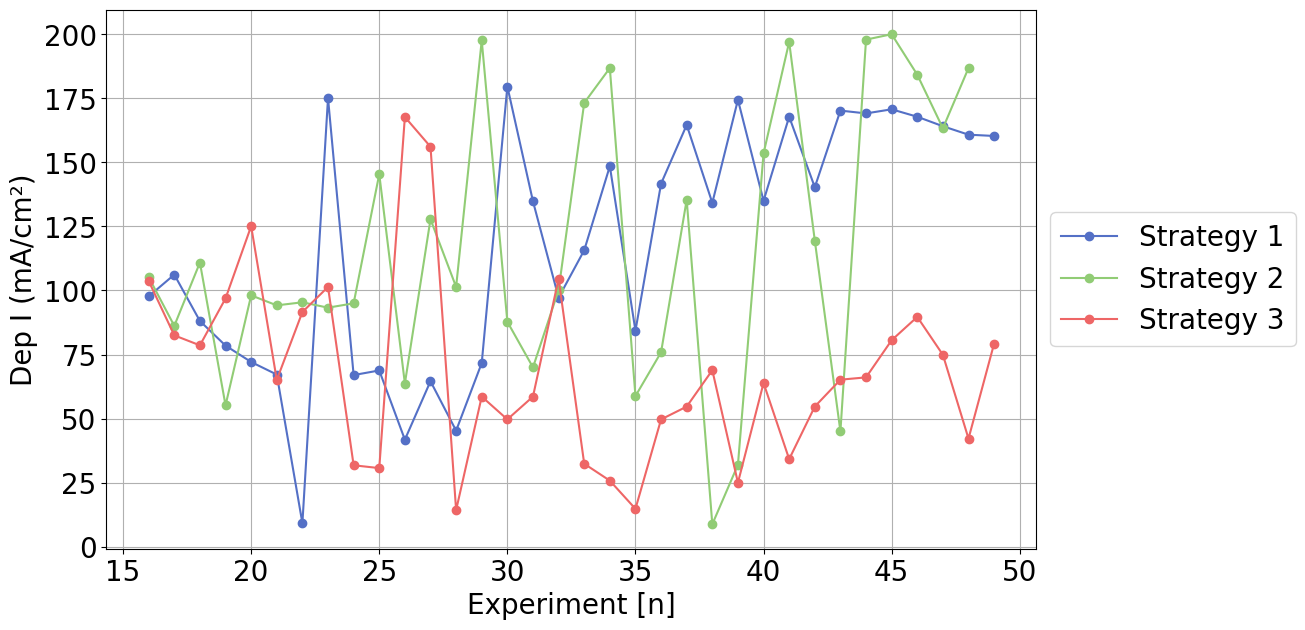

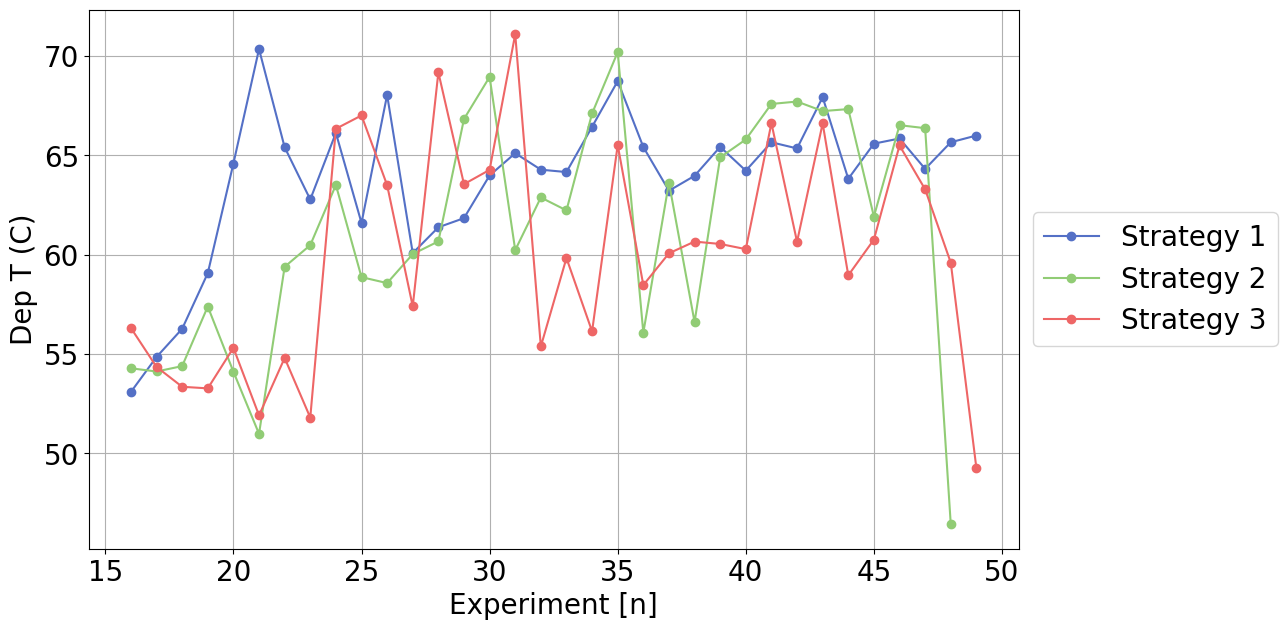

In [ ]:
colors = ["#91cc75", "#5470c6", "#ee6666", "red", "purple", "black"]

params = [
    "NiSO4 (mol/L)",  
    "Na2Mo (mol/L)",  
    "H2SO4 (mol/L)", 
    "Dep t (s)", 
    "Dep I (mA/cm²)", 
    "Dep T (C)"
]

colors = {"Strategy 1" : "#5470c6",
          "Strategy 2" : "#91cc75", 
          "Strategy 3": "#ee6666"}
datasets = [df_beta_1,df_beta_5,  df_og]

print(df_beta_1.columns)
labels = ["Strategy 1", "Strategy 2", "Strategy 3"]
for i, param in enumerate(params):
    plt.figure(figsize = (12, 7))
    for idx, data in enumerate(datasets):

        # Make sure the DataFrame is sorted by time or index
        data = data.copy().reset_index(drop=True)

        # Plot each parameter vs experiment iteration
        n_params = len(params)
        color = colors[f"Strategy {idx + 1}"]
        try:

            plt.plot(data.index[16:50], data[param][16:50], marker='o', linestyle='-', color = color, label = labels[idx])
        except:
            plt.plot(data.index[16:], data[param][16:], marker='o', linestyle='-', color = color, label = labels[idx])
    plt.ylabel(param, fontsize = 20)
    plt.xlabel("Experiment [n]", fontsize = 20)
    plt.grid()
    
    plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=20)
    plt.xticks(fontsize = 20)
    plt.yticks(fontsize = 20)
    if param == 'Dep t (s)':
        param_str = "Dep_t_s"
    else:
        param_str = param.split(" (")[0]
    plt.savefig(f"model_paths_{param_str}.png", bbox_inches="tight")

    plt.show()



# Investigaing best points in each bracket

In [ ]:
# Define the columns to print
import matplotlib.pyplot as plt

# Work on copies instead of modifying the original DataFrames
df_beta_5_mod = df_beta_5.copy()
df_beta_1_mod = df_beta_1.copy()
df_og_mod     = df_og.copy()

n_to_show = 10
# Apply transformations

df_beta_5_mod["C_dep"] = df_beta_5_mod["Dep I (mA/cm²)"] * df_beta_5_mod["Dep t (s)"] / 96485
df_beta_5_mod["Citrate (mol/L)"] = df_beta_5_mod["NiSO4 (mol/L)"] + df_beta_5_mod['Na2Mo (mol/L)'] 
df_beta_5_mod["NiSO4 (mol/L)"] = df_beta_5_mod["NiSO4 (mol/L)"] + df_beta_5_mod['Na2Mo (mol/L)'] * 0.1
df_beta_5_mod['Na2Mo (mol/L)'] = df_beta_5_mod['Na2Mo (mol/L)'] + df_beta_5_mod["NiSO4 (mol/L)"] * 0.1

df_beta_1_mod["C_dep"] = df_beta_1_mod["Dep I (mA/cm²)"] * df_beta_1_mod["Dep t (s)"]/ 96485
df_beta_1_mod["Citrate (mol/L)"] = df_beta_1_mod["NiSO4 (mol/L)"] + df_beta_1_mod['Na2Mo (mol/L)'] 
df_beta_1_mod["NiSO4 (mol/L)"] = df_beta_1_mod["NiSO4 (mol/L)"] + df_beta_1_mod['Na2Mo (mol/L)'] * 0.1
df_beta_1_mod['Na2Mo (mol/L)'] = df_beta_1_mod['Na2Mo (mol/L)'] + df_beta_1_mod["NiSO4 (mol/L)"] * 0.1

df_og_mod["C_dep"] = df_og_mod["Dep I (mA/cm²)"] * df_og_mod["Dep t (s)"]/ 96485
df_og_mod["Citrate (mol/L)"] = df_og_mod["NiSO4 (mol/L)"] + df_og_mod['Na2Mo (mol/L)'] 
df_og_mod["NiSO4 (mol/L)"] = df_og_mod["NiSO4 (mol/L)"] + df_og_mod['Na2Mo (mol/L)'] * 0.1
df_og_mod['Na2Mo (mol/L)'] = df_og_mod['Na2Mo (mol/L)'] + df_og_mod["NiSO4 (mol/L)"] * 0.1


columns_to_show = ["NiSO4 (mol/L)", "Na2Mo (mol/L)", "H2SO4 (mol/L)", 
                   "Dep t (s)", "Dep I (mA/cm²)","C_dep", "Dep T (C)", "Citrate (mol/L)", "integrated_area", "timestamp", ]

# Create top and bottom DataFrames for each strategy (on modified copies)
tail_beta_5 = df_beta_5_mod.sort_values("integrated_area").tail(n_to_show)[columns_to_show]
head_beta_5 = df_beta_5_mod.sort_values("integrated_area").head(n_to_show)[columns_to_show]

tail_beta_1 = df_beta_1_mod.sort_values("integrated_area").tail(n_to_show)[columns_to_show]
head_beta_1 = df_beta_1_mod.sort_values("integrated_area").head(n_to_show)[columns_to_show]

tail_og = df_og_mod.sort_values("integrated_area").tail(n_to_show)[columns_to_show]
head_og = df_og_mod.sort_values("integrated_area").head(n_to_show)[columns_to_show]

F = 96485

# Print results
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print("-" * 25, "Strategy 3", "_" * 25)
    print(head_og)
    print()
    print("-" * 25, "Strategy 2", "_" * 25)
    print(head_beta_5)
    print()
    print("-" * 25, "Strategy 1", "_" * 25)
    print(head_beta_1)
    print("-" * 50)


from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA

complete_dataset = pd.concat([df_beta_1, df_beta_5, df_og], ignore_index=True) 



complete_dataset["C_dep"] = complete_dataset["Dep I (mA/cm²)"] * complete_dataset["Dep t (s)"]

features = ["NiSO4 (mol/L)", "Na2Mo (mol/L)", "H2SO4 (mol/L)", 
            "Dep t (s)", "Dep I (mA/cm²)", "Dep T (C)"]

scaler = PowerTransformer(method='yeo-johnson')

X = complete_dataset[features].values
X_scaled = scaler.fit_transform(complete_dataset[features])

print(X_scaled)
# Run PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_scaled)

# Add PCA results to DataFrame
complete_dataset["PC1"] = pca_result[:, 0]
complete_dataset["PC2"] = pca_result[:, 1]
complete_dataset["PC3"] = pca_result[:, 2]

import plotly.express as px

fig = px.scatter_3d(
    complete_dataset,
    x="PC1",
    y="PC2",
    z="PC3",
    color="integrated_area",
    color_continuous_scale="RdBu",  # equivalent to 'coolwarm_r'
    opacity=0.9,

)

fig.update_traces(marker=dict(size=4))

fig.update_layout(
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    ),
    coloraxis_colorbar=dict(title="Integrated Area"),
    title="PCA of Experimental Conditions",
    margin=dict(l=0, r=0, b=0, t=30)
)

fig.show()

------------------------- Strategy 3 _________________________
    NiSO4 (mol/L)  Na2Mo (mol/L)  H2SO4 (mol/L)  Dep t (s)  Dep I (mA/cm²)     C_dep  Dep T (C)  Citrate (mol/L)  integrated_area         timestamp
37         0.1156        0.04756          0.095      533.5            54.7  0.302456      60.07            0.148      6313.177205  06.05.2025_16-03
38         0.1448        0.06248          0.095      600.0            68.9  0.428460      60.66            0.188      6585.384448  06.05.2025_17-44
73         0.2214        0.05614          0.090      119.9           134.0  0.166519      66.10            0.252      6788.548841  11.05.2025_11-57
42         0.0798        0.06598          0.095      600.0            54.7  0.340157      60.65            0.132      6811.037222  07.05.2025_00-39
77         0.1064        0.07464          0.090      305.7            45.0  0.142577      65.07            0.164      7259.314944  11.05.2025_18-10
74         0.0664        0.07064          0.095  

# Looking at distribution of samples

$\mathbf{NiSO_4}$ (M)
$\mathbf{Na_2MoO_4}$ (M)
$\mathbf{H_2SO_4}$ (M)
Dep t (s)
Dep I (mA/cm²)
Dep T (C)


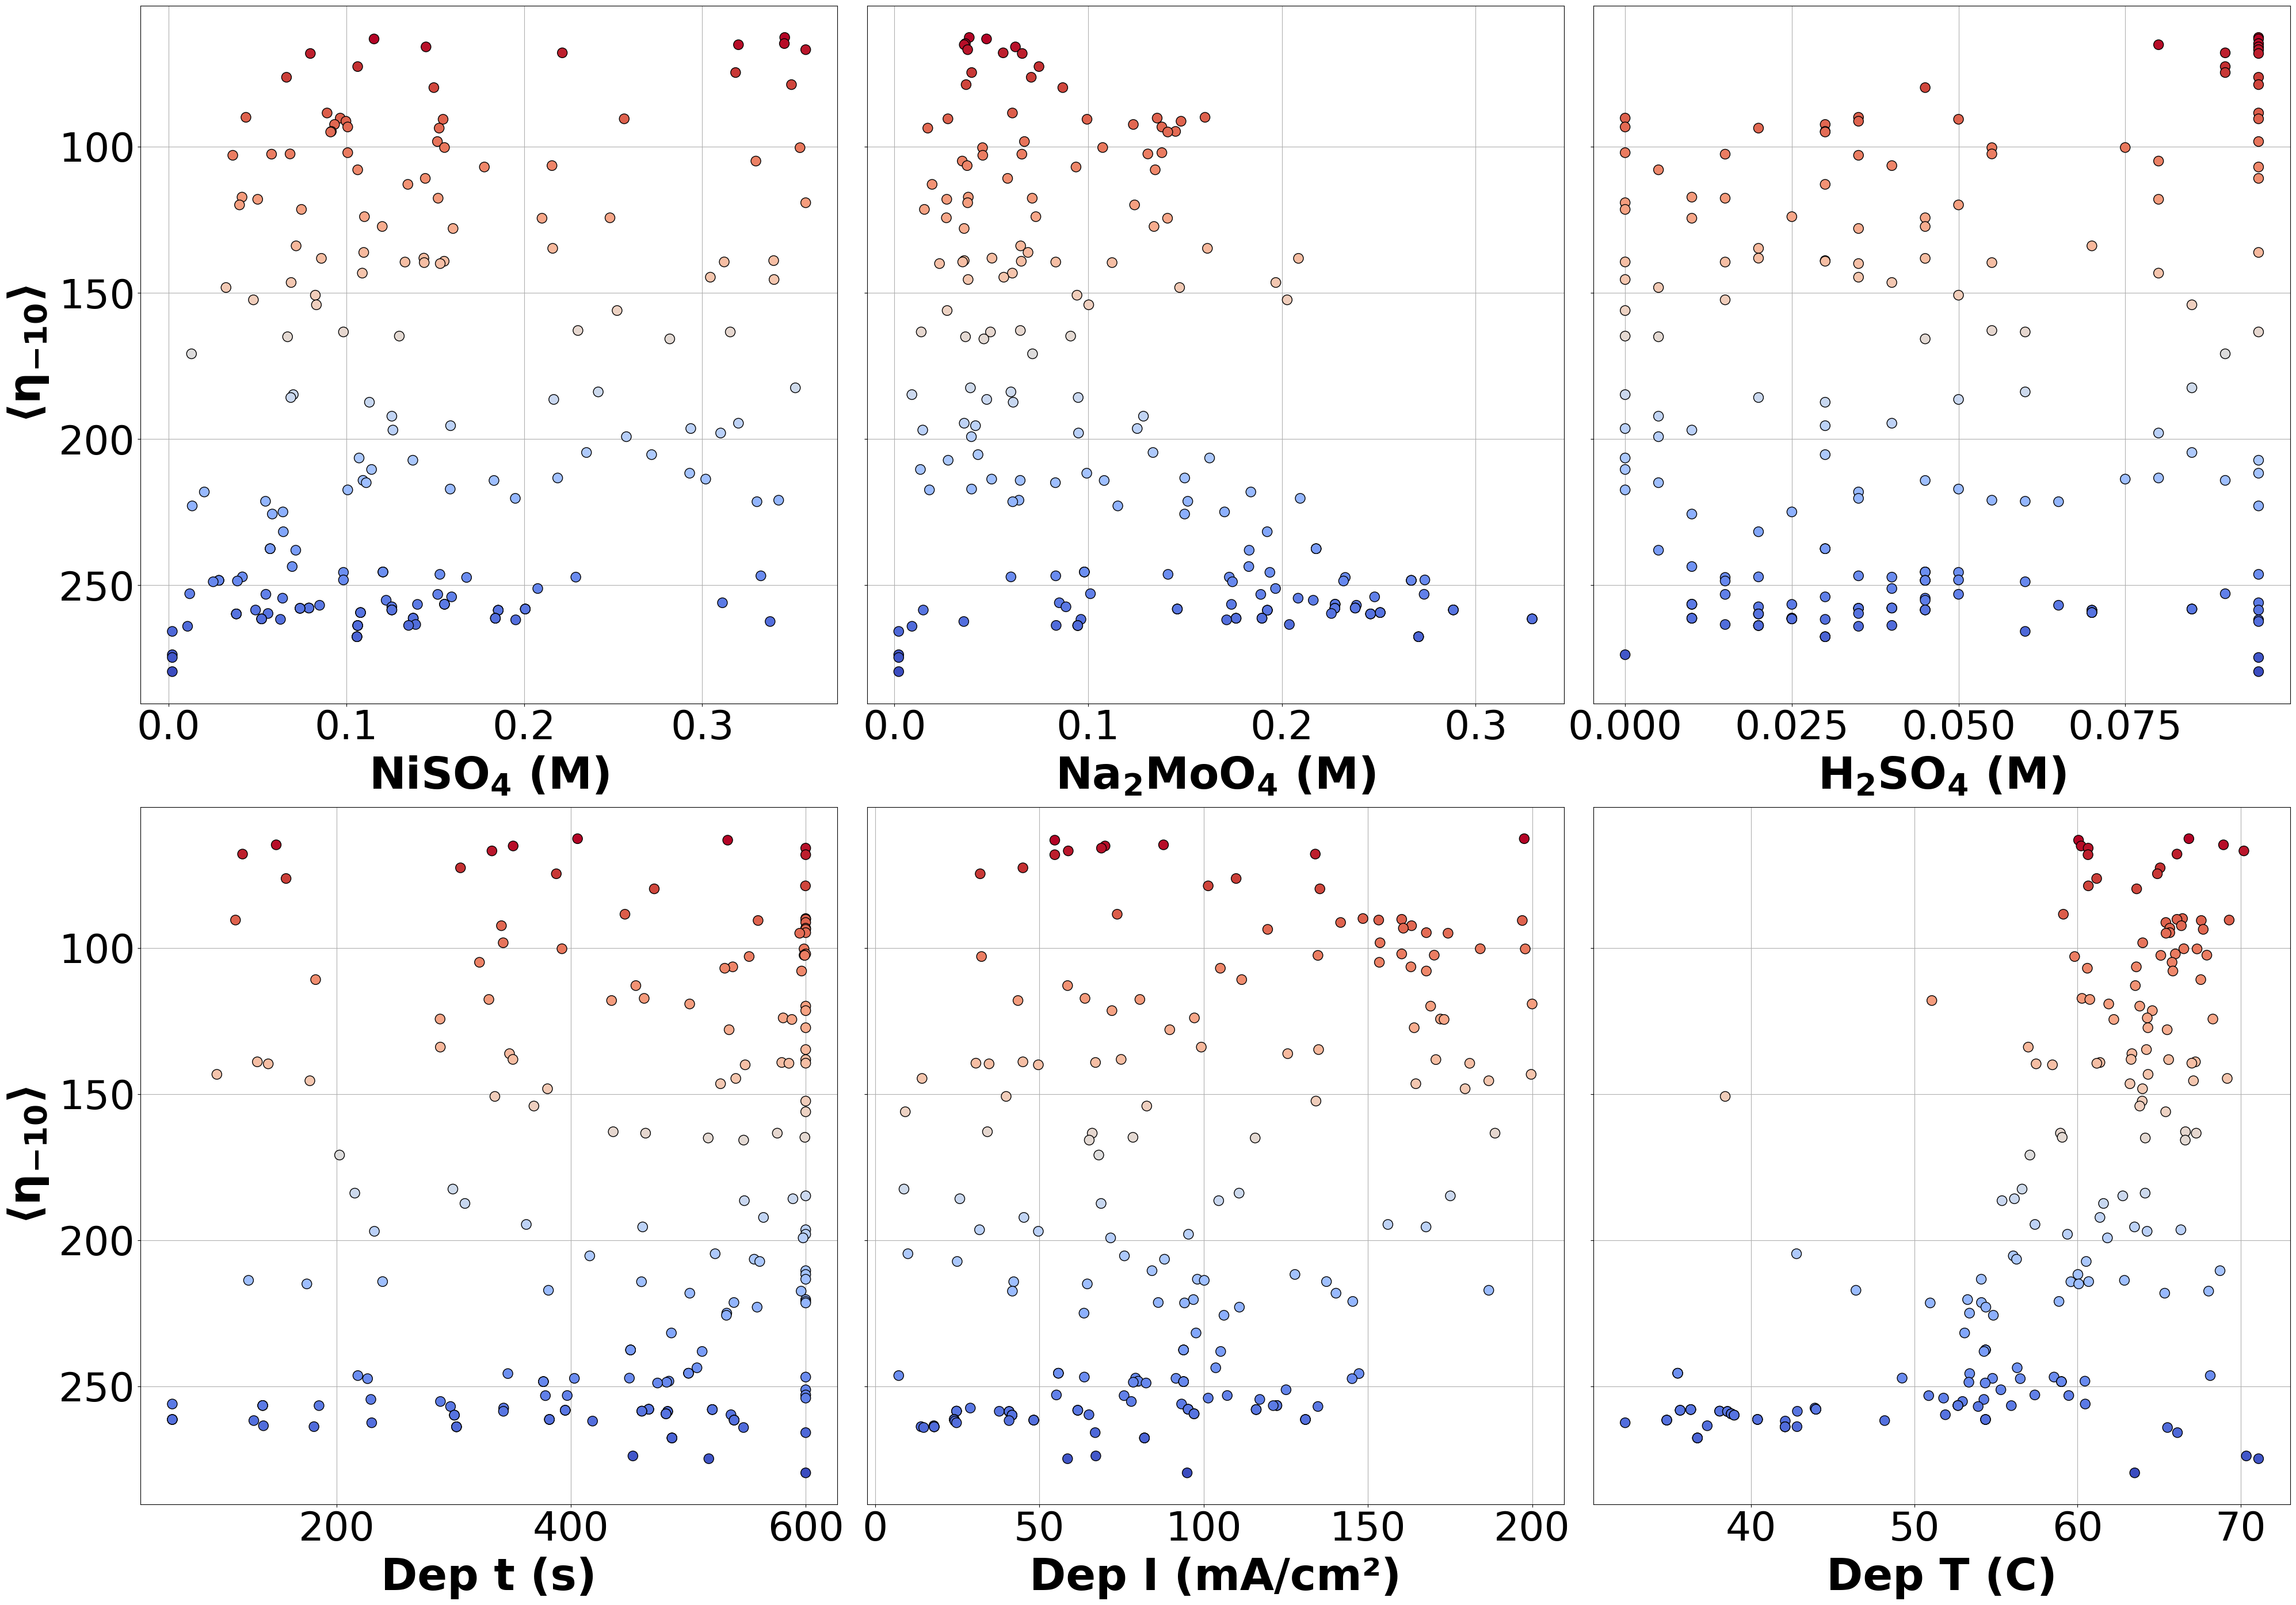

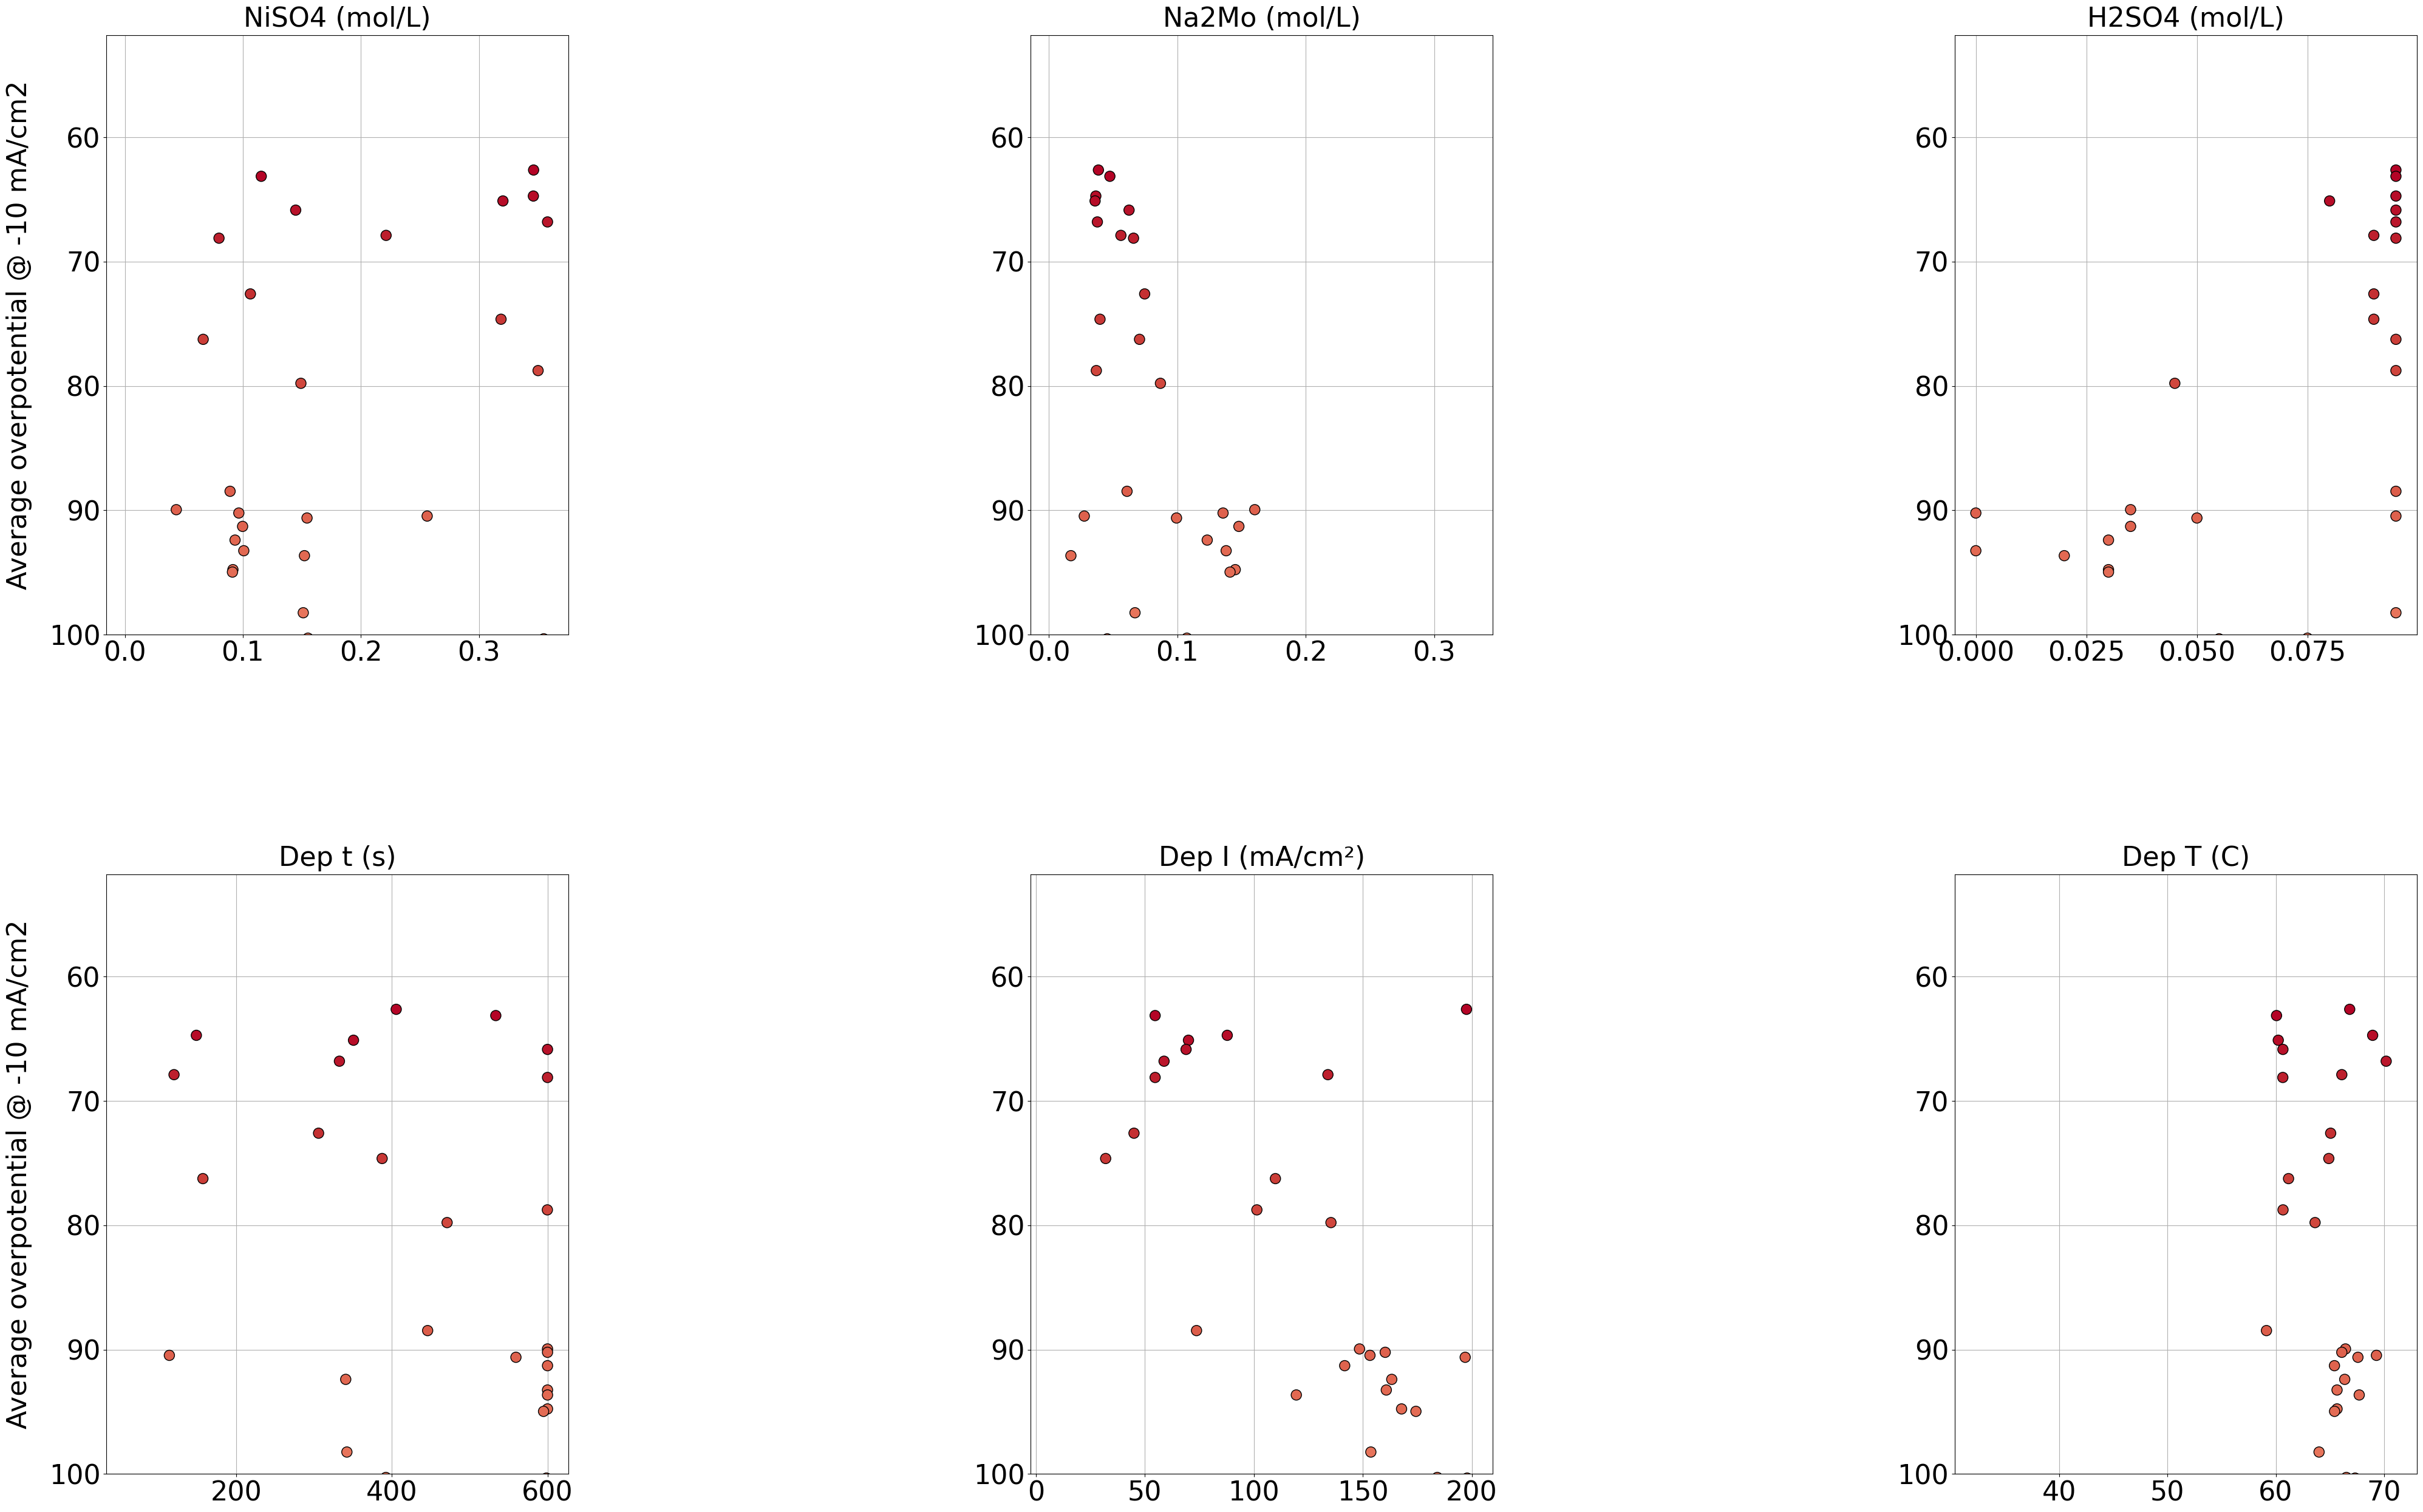

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import math 

# Combine datasets
complete_dataset = pd.concat([df_og, df_beta_5, df_beta_1], ignore_index=True)
complete_dataset.to_csv("complete_dataset.csv", index=False)
# Temperature in Kelvin
T = complete_dataset["Dep T (C)"] + 273.15

# Concentrations


# Compute D values and add to DataFrame
eV = 1.6 * 10 ** (-19)
kB = 1.38 * 10 ** (-23)

complete_dataset["C_dep"] = complete_dataset["Dep I (mA/cm²)"] * complete_dataset["Dep t (s)"] / 1000 * 0.97

complete_dataset["NiSO4 (mol/L)"] = complete_dataset["NiSO4 (mol/L)"] + complete_dataset['Na2Mo (mol/L)'] * 0.1
complete_dataset['Na2Mo (mol/L)'] = complete_dataset['Na2Mo (mol/L)'] + complete_dataset["NiSO4 (mol/L)"] * 0.1

C_Ni_SO4 = complete_dataset["NiSO4 (mol/L)"]
C_Na2Mo = complete_dataset["Na2Mo (mol/L)"]
complete_dataset["D_Ni"] = np.exp(-C_Ni_SO4 / (T))
complete_dataset["D_Mo"] = np.exp(-1 / (C_Na2Mo * T))
complete_dataset["Ni_Mo_r"] = C_Ni_SO4 / C_Na2Mo

# Update parameters for plotting
params = ["NiSO4 (mol/L)",  'Na2Mo (mol/L)', 'H2SO4 (mol/L)', 
          'Dep t (s)', 'Dep I (mA/cm²)', 'Dep T (C)']

# Sort and select
sorted_df = complete_dataset.copy().sort_values(by="integrated_area").reset_index(drop=True)

# Normalize integrated_area for color mapping
norm = plt.Normalize(sorted_df["integrated_area"].min(), sorted_df["integrated_area"].max())
colors = cm.coolwarm_r(norm(sorted_df["integrated_area"]))

savepath_params = "/Users/pvifr/Desktop/ElectrochemicalDataAnalysis/Ni_Mo_paper/Plots_paper"
# Plot
fig, axes = plt.subplots(math.ceil(len(params) / 3), 3, figsize=(40, 28),sharey=True)  # Now 3x3 for 8 plots

axes = axes.flatten()
n_rows = math.ceil(len(params) / 2)

for i, param in enumerate(params):
    x_data = sorted_df[param]
    if param == "Na2Mo (mol/L)":
        param = r"$\mathbf{Na_2MoO_4}$ (M)"
    if param == "NiSO4 (mol/L)":
        param = r"$\mathbf{NiSO_4}$ (M)"
    if param == 'H2SO4 (mol/L)':
        param = r"$\mathbf{H_2SO_4}$ (M)"
    print(param)
    #axes[i].set_xlabel(param, fontsize=28)

    axes[i].scatter(
        x_data,
        sorted_df["integrated_area"] / 100,
        c=colors,
        edgecolors='k',
        s=150,  # dot size,
        zorder = 10
    )
    if i == 0:
        axes[0].invert_yaxis()
    #axes[i].set_title(param, fontsize=55, pad = 10)
    axes[i].set_xlabel(param, 
                    fontsize=55, 
                    labelpad=10, 
                    fontweight='bold')  # makes label bold
    axes[i].tick_params(axis='both', labelsize=50)
    if (i == 0 or i == 3):
        axes[i].set_ylabel(r"$\mathbf{\langle \eta_{-10} \rangle}$", 
                   fontsize=55, labelpad=10)

    axes[i].grid(True)
plt.subplots_adjust(hspace=0.15)
plt.tight_layout()

plt.savefig(os.path.join(savepath_params, "Param_dependencies.png"))
# Hide any unused subplot axes (if 9 total axes but only 8 params)
for j in range(len(params), len(axes)):
    fig.delaxes(axes[j])
# Prepare data
#top = complete_dataset[complete_dataset["Dep T (C)"] > 50].sort_values("integrated_area").head(10)
#print(top)
#print(top[["NiSO4 (mol/L)", "Na2Mo (mol/L)", "Dep I (mA/cm²)", 'H2SO4 (mol/L)', "Dep T (C)", "Dep t (s)", "integrated_area"]])
fig, axes = plt.subplots(math.ceil(len(params) / 3), 3, figsize=(40, 25))  # Now 3x3 for 8 plots
axes = axes.flatten()
n_rows = math.ceil(len(params) / 2)

for i, param in enumerate(params):
    x_data = sorted_df[param]
    if param == "Na2Mo":
        param = r"$Na_2MoO_4$"
    if param == "Na2Mo":
        param = r"$Na_2Mo_O_4$"
    if param == "Na2Mo":
        param = r"$Na_2Mo_O_4$"
    #axes[i].set_xlabel(param, fontsize=28)

    axes[i].scatter(
        x_data,
        sorted_df["integrated_area"] / 100,
        c=colors,
        edgecolors='k',
        s=150,  # dot size,
        zorder = 10
    )
    axes[i].set_title(param, fontsize=32, pad = 10)
    axes[i].tick_params(axis='both', labelsize=32)
    if (i == 0 or i == 3):
        axes[i].set_ylabel("Average overpotential @ -10 mA/cm2", fontsize=32, labelpad = 20)
    axes[i].invert_yaxis()
    axes[i].set_ylim(bottom=100)
    axes[i].grid(True)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=1)
plt.savefig(os.path.join(savepath_params, "Param_dependencies_closeup.png"))


# Spider plots of best runs for both

# Investigating the dependence on total amount deposited

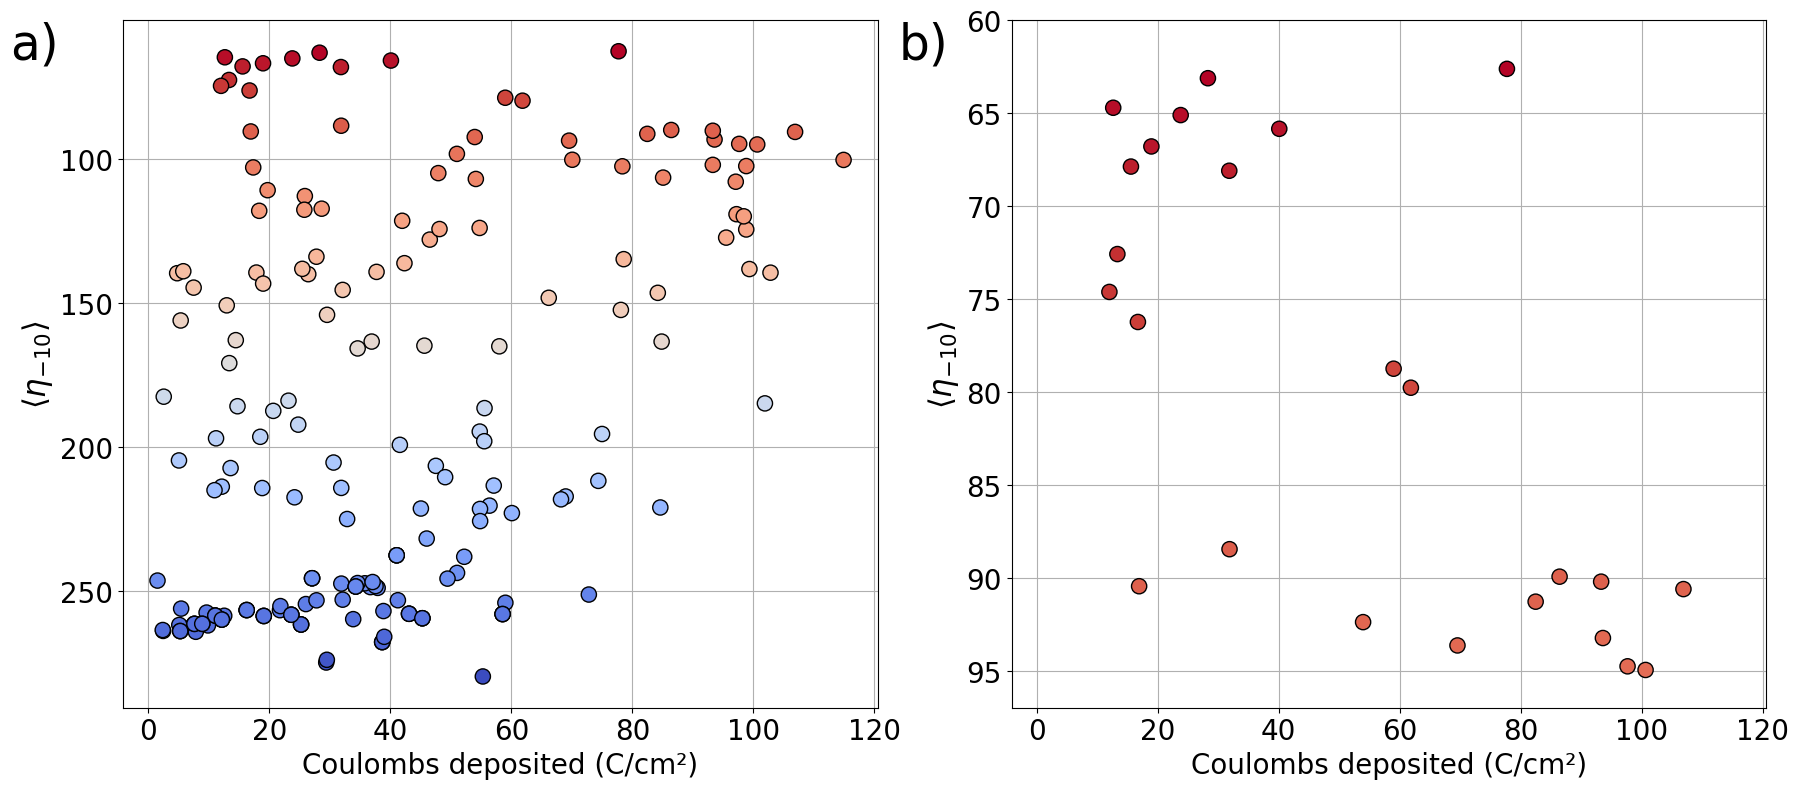

In [26]:
# --------------------------------------------------
# PLOT: FULL + CLOSEUP
# -------------------------------------------------
# -
df = complete_dataset.copy()

x = df["C_dep"]
y = df["integrated_area"] / 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax in axes:
    ax.tick_params(axis='both', labelsize=20)  # 🔥 big tick labels

# -------- LEFT: FULL RANGE --------

x_data = sorted_df["C_dep"]

axes[0].scatter(
    x, y,
    c=colors,
    edgecolors='k',
    s=120,
    zorder=10
)
axes[0].invert_yaxis()
axes[0].set_xlabel("Coulombs deposited (C/cm²)", fontsize=20)
axes[0].set_ylabel(r"$\langle \eta_{-10} \rangle$", fontsize=22)
axes[0].grid(True)

# -------- RIGHT: CLOSEUP --------
axes[1].scatter(
    x, y,
    c=colors,
    edgecolors='k',
    s=120,
    zorder=10
)
axes[1].invert_yaxis()

# Zoom window
#axes[1].set_xlim(x.quantile(0.0), x.quantile(0.3))
axes[1].set_ylim(97,60)


axes[1].set_xlabel("Coulombs deposited (C/cm²)", fontsize=20)
axes[1].set_ylabel(r"$\langle \eta_{-10} \rangle$", fontsize=22)
axes[1].grid(True)
# -------- PANEL LABELS --------
axes[0].text(
    -0.15, 1, "a)",
    transform=axes[0].transAxes,
    fontsize=35,
    va='top'
)

axes[1].text(
    -0.15, 1, "b)",
    transform=axes[1].transAxes,
    fontsize=35,
    va='top'
)
plt.tight_layout()
plt.savefig(os.path.join(savepath_params, "Dependence coulomb deposit.png"))
plt.show()

In [ ]:
from pHfork import AcidAq, IonAq, System
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure your dataset is available as complete_dataset
df = complete_dataset.copy()

# Compute total citrate concentration
df["cit_total"] = df["NiSO4 (mol/L)"] + df["Na2Mo (mol/L)"]


citric = AcidAq(pKa=[3.1, 4.8, 6.4], charge=3, conc=0.4)

system = System(citric)

system.pHsolve()
print(system.pH)




phs = []
# Loop through dataset rows
for i, row in df.iterrows():
    cit_conc = row["cit_total"]


    h2so4 = row["H2SO4 (mol/L)"]
    # Define species in solution
    citric = AcidAq(pKa=[3.1, 4.8, 6.4], charge=2.9, conc=cit_conc)
    protons = IonAq(charge=-2, conc=h2so4)      # From H2SO4 → 2 H⁺
    
    # Setup system
    system = System(citric, protons)
    
    system.pHsolve()
    phs.append(system.pH)

# Plot first N results
N = 100

print(phs[0:N])
plt.scatter(np.arange(N) + 1, phs[:N], s = 60)
plt.xlabel("[H₂SO₄] added (mol/L)", fontsize=14)
plt.ylabel("pH", fontsize=14)
plt.title("pH vs H₂SO₄ Addition", fontsize=16)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Temperature in Kelvin
T = df["Dep T (C)"] + 273.15

# Concentrations
C_Ni_SO4 = df["NiSO4 (mol/L)"]
C_Na2Mo = df["Na2Mo (mol/L)"]
df["pH"] = phs
complete_dataset["pH"] = phs
# Compute D values and add to DataFrame
eV = 1.6 * 10 ** (-19)
kB = 1.38 * 10 ** (-23)
df["D_Ni"] = np.exp(-C_Ni_SO4 / (T))
df["D_Mo"] = np.exp(-1 / (C_Na2Mo * T))

# Update parameters for plotting
params = ['NiSO4 (mol/L)', 'Na2Mo (mol/L)', "pH", 
          'Dep t (s)', 'Dep I (mA/cm²)', 'Dep T (C)']

# Sort and select
sorted_df = df.copy().sort_values(by="integrated_area").reset_index(drop=True)

# Normalize integrated_area for color mapping
norm = plt.Normalize(sorted_df["integrated_area"].min(), sorted_df["integrated_area"].max())
colors = cm.coolwarm(norm(sorted_df["integrated_area"]))

# Plot
fig, axes = plt.subplots(2, 3, figsize=(25, 18))  # Now 3x3 for 8 plots
axes = axes.flatten()

for i, param in enumerate(params):
    x_data = sorted_df[param]
    
    axes[i].set_xlabel(param, fontsize=22)

    axes[i].scatter(
        x_data,
        sorted_df["integrated_area"],
        c=colors,
        edgecolors='k',
        s=150,  # dot size,
        zorder = 10
    )
    axes[i].set_title(param, fontsize=24)
    axes[i].tick_params(axis='both', labelsize=20)
    axes[i].grid(True)

# Hide any unused subplot axes (if 9 total axes but only 8 params)
for j in range(len(params), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("lowest_integrated_area_plots.png", dpi=300)
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import pdist, squareform
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import seaborn as sns
import pickle 
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from scipy.signal import savgol_filter
import math

pkl_file = "/Users/pvifr/Desktop/ElectrochemicalDataAnalysis/DataAnalysisSecondPhaseCatBot/Ni_Mo_Second_run/pkl_files/Ni_Mo_OP_evolutions.pkl"
with open(pkl_file, 'rb') as file:
    data = pickle.load(file)


def summarize_param_range(params_list, param_key):
    values = [p[param_key] for p in params_list if param_key in p and isinstance(p[param_key], (int, float))]
    if not values:
        return ""
    return f"{param_key}: {min(values):.2f}–{max(values):.2f}"

def moving_average(curve, window_size=5):
    return np.convolve(curve, np.ones(window_size)/window_size, mode='same')



keys = list(data.keys())

integrated_areas = []
all_params = []

filtered_data = {}
curves = []

df_copy = complete_dataset.copy()

# Format the 'timestamp' column in the copied DataFrame
df_copy["timestamp_formatted"] = df_copy["timestamp"].astype(str).str.replace(".", "_", regex=False).str.replace("-", "_", regex=False)
df_timestamps = df_copy["timestamp_formatted"].to_list()

for i, exp_i in enumerate(keys):
   
    try:
        raw_timestamp = data[exp_i]['params']['exp_name'].split("/")[-1].split("__")[0].split("data_")[-1]
        #reformatted = datetime.strptime(raw_timestamp, "%d.%m.%Y_%H-%M").strftime("%d_%m_%Y_%H_%M")

        if raw_timestamp in df_timestamps:

            y = data[exp_i][10]
            curve = np.array(np.abs(y))

            integrated_area = np.trapz(curve)# Integrate y

            if len(curve) != 100:
                continue
            
            integrated_areas.append(integrated_area)
            curve = savgol_filter(curve, window_length=5, polyorder=2)
            #curve = moving_average(curve, window_size=3)
            params = data[exp_i]["params"]
            all_params.append(data[exp_i]["params"])

            curves.append(curve)

    except Exception as e:
        print(e)
        continue

print(all_params)
curves = np.array(curves)
integrated_areas = np.array(integrated_areas)

curves = np.array(curves)
integrated_areas = np.array(integrated_areas)
all_params = np.array(all_params)

# Get sorting indices based on integrated area (descending or ascending)
sorted_indices = np.argsort(integrated_areas)[::-1]  # Use [::-1] for descending

# Sort curves, areas, and params accordingly
curves = curves[sorted_indices]
integrated_areas = integrated_areas[sorted_indices]
all_params = all_params[sorted_indices]

print(all_params[::-1][0:2])
for i, curve in enumerate(curves[::-1][0:2]):
    plt.plot(curve)

plt.legend()
plt.title("Curves sorted by integrated area")
plt.show()



/var/folders/y7/nkq5y8bx3nl3kcn3ndsw71t80000gp/T/ipykernel_3578/1557710530.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_optimization_run_march_filtered['source'] = 'march'


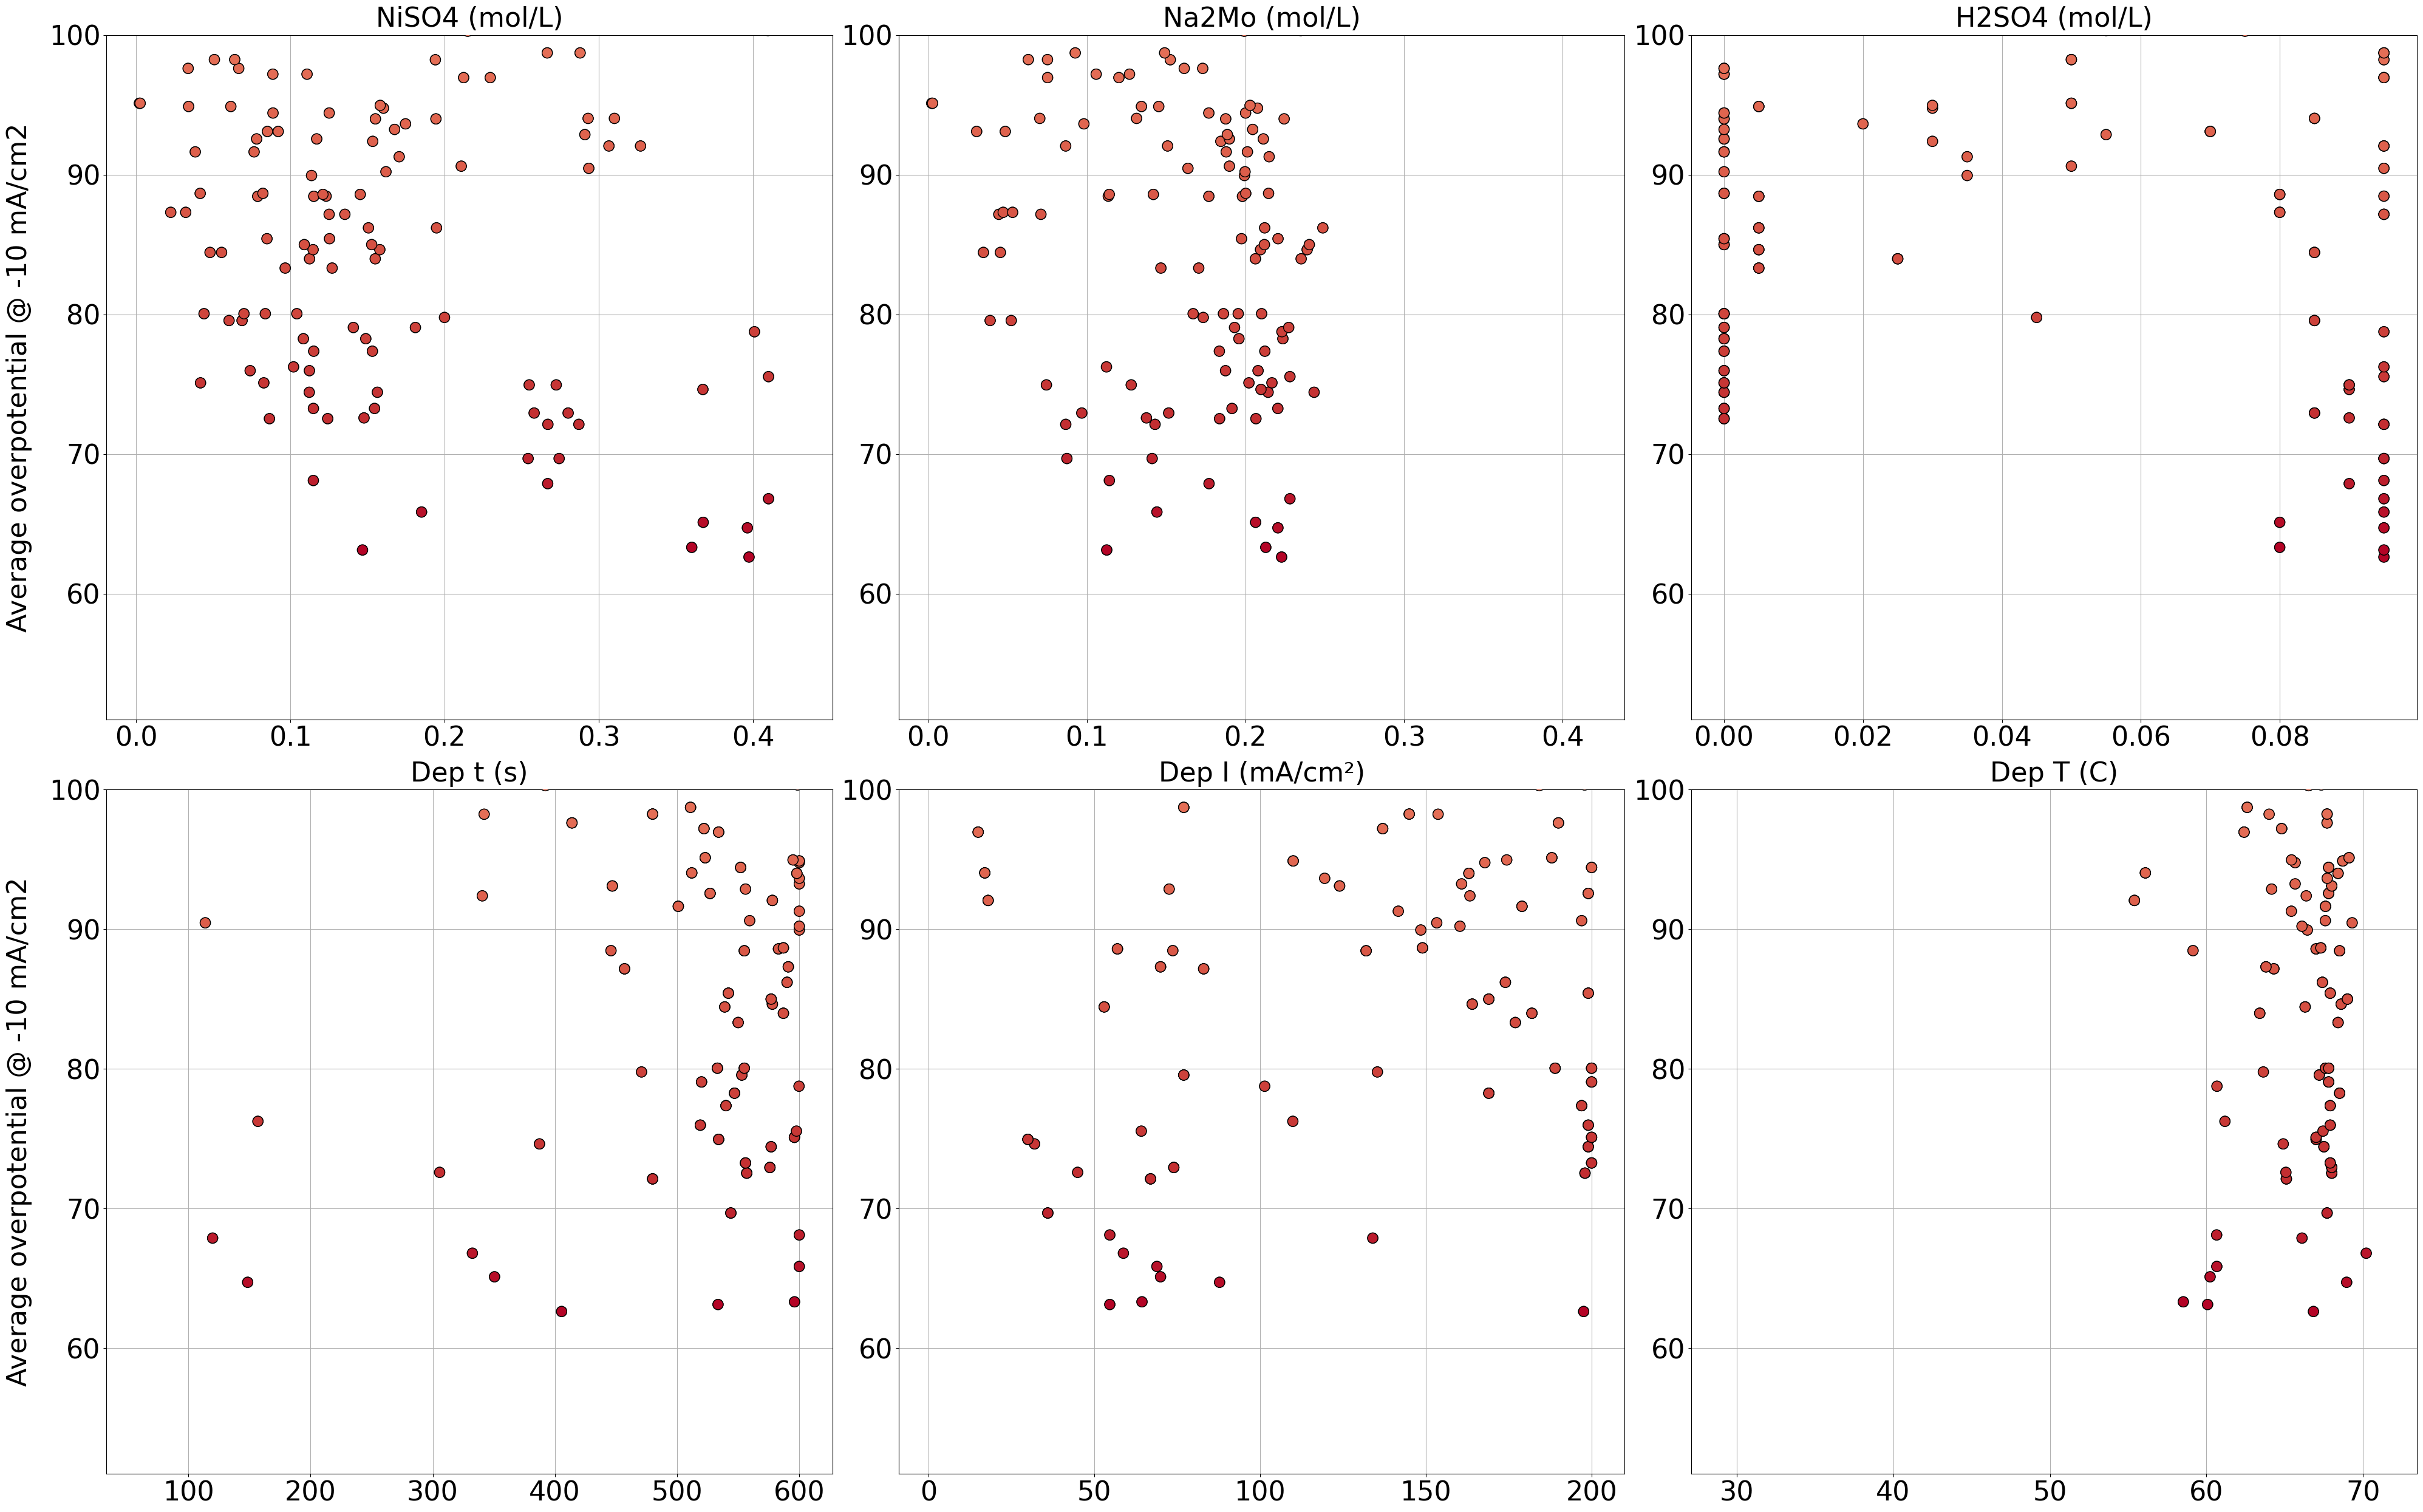

In [25]:
# Combining all the datasets
dataset_optimization_run_march = pd.read_csv("/Users/pvifr/Desktop/ElectrochemicalDataAnalysis/DataAnalysisSecondPhaseCatBot/integrated_areas_modified.csv", sep=';')

common_columns = [col for col in dataset_optimization_run_march.columns if col in complete_dataset.columns]

dataset_optimization_run_march_filtered = dataset_optimization_run_march[common_columns]
complete_dataset_filtered = complete_dataset[common_columns]

dataset_optimization_run_march_filtered['source'] = 'march'
complete_dataset_filtered['source'] = 'may'

complete_dataset_filtered["NiSO4 (mol/L)"] = complete_dataset_filtered["NiSO4 (mol/L)"] + complete_dataset_filtered['Na2Mo (mol/L)'] * 0.1
complete_dataset_filtered['Na2Mo (mol/L)'] = complete_dataset_filtered['Na2Mo (mol/L)'] + complete_dataset_filtered["NiSO4 (mol/L)"] * 0.1


combined_dataset = pd.concat([complete_dataset_filtered, dataset_optimization_run_march_filtered], ignore_index=True)

complete_dataset = combined_dataset

# Temperature in Kelvin
T = complete_dataset["Dep T (C)"]

complete_dataset["NiSO4 (mol/L)"] = complete_dataset["NiSO4 (mol/L)"] + complete_dataset['Na2Mo (mol/L)'] * 0.1
complete_dataset['Na2Mo (mol/L)'] = complete_dataset['Na2Mo (mol/L)'] + complete_dataset["NiSO4 (mol/L)"] * 0.1

# Update parameters for plotting
params = ["NiSO4 (mol/L)",  'Na2Mo (mol/L)', 'H2SO4 (mol/L)', 
          'Dep t (s)', 'Dep I (mA/cm²)', 'Dep T (C)']

# Sort and select
sorted_df = complete_dataset.copy().sort_values(by="integrated_area").reset_index(drop=True)

# Normalize integrated_area for color mapping
norm = plt.Normalize(sorted_df["integrated_area"].min(), sorted_df["integrated_area"].max())
colors = cm.coolwarm_r(norm(sorted_df["integrated_area"]))
savepath_params = "/Users/pvifr/Desktop/ElectrochemicalDataAnalysis/DataAnalysisSecondPhaseCatBot/Ni_Mo_Second_run/Figures"
# Plot
fig, axes = plt.subplots(2, 3, figsize=(40, 25))  # Now 3x3 for 8 plots
axes = axes.flatten()
n_rows = math.ceil(len(params) / 2)

for i, param in enumerate(params):
    x_data = sorted_df[param]
    
    #axes[i].set_xlabel(param, fontsize=28)

    axes[i].scatter(
        x_data,
        sorted_df["integrated_area"] / 100,
        c=colors,
        edgecolors='k',
        s=150,  # dot size,
        zorder = 10
    )
    axes[i].set_title(param, fontsize=32, pad = 10)
    axes[i].tick_params(axis='both', labelsize=32)
    if (i == 0 or i == 3):
        axes[i].set_ylabel("Average overpotential @ -10 mA/cm2", fontsize=32, labelpad = 20)

    axes[i].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(savepath_params, "Param_dependencies_march_may_datasets.png"))


for i, param in enumerate(params):
    x_data = sorted_df[param]
    
    #axes[i].set_xlabel(param, fontsize=28)

    axes[i].scatter(
        x_data,
        sorted_df["integrated_area"] / 100,
        c=colors,
        edgecolors='k',
        s=150,  # dot size,
        zorder = 10
    )
    axes[i].set_title(param, fontsize=32, pad = 10)
    axes[i].tick_params(axis='both', labelsize=32)
    if (i == 0 or i == 3):
        axes[i].set_ylabel("Average overpotential @ -10 mA/cm2", fontsize=32, labelpad = 20)
    axes[i].set_ylim(top=100)
    axes[i].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(savepath_params, "Param_dependencies_march_may_datasets_closeup.png"))




In [3]:
print(12
     / (15 / 1000))

800.0
